# Introduction

This notebook develops **per-hospital** machine-learning forecasts for **daily cases** and **daily revenue** at the **specialty** level (or **sub-specialty** when a hospital has only one specialty). Each hospital is modeled independently to avoid cross-site bias and to reflect local operating conditions.

## Business Purpose
- Forecast **cases** and **revenue** per **Hospital × (Specialty/Sub-specialty) × Day**.
- Identify **top-performing specialties** to support planning, staffing, and budget decisions.

## Data Inputs
- **Hours/Workload:** `ActualWorkingHours`, `PlannedWorkingHours`, `No_of_Clinic`, `No_Of_Actual_Slots` (≈ cases), with staff, hospital, (sub)specialty, and date.
- **Revenue:** `TotalRevenue` by hospital, staff, and date.

## Scope & Grain
- Analysis grain: **ShortName × (Speciality / SubSpeciality) × Date**.
- One model **per hospital and per (sub)specialty**.
- Targets: **Cases** (`No_Of_Actual_Slots`) and **Revenue** (`TotalRevenue`).

## Preprocessing (Per Unit)
- Normalize keys and dates; merge hours with revenue.
- Fallback rule: use **Speciality**; if only one specialty exists, use **SubSpeciality**.
- Data quality: clip negatives; optional winsorization (1st–99th percentile).
- Calendar features: `Year`, `Month`, `DayOfWeek`, `IsWeekend`.

## Modeling
- Time-aware split (last 20% of dates = test).
- **Multi-output regression** for Cases & Revenue with numeric and categorical features.
- Baselines (train-mean) and evaluation via **RMSE/MAE**.

## Outputs
- Clean table: `agg_unit_cleaned`.
- Per-unit metrics and test-set predictions.
- Graphs: top specialties by predicted **total** and **average daily** revenue; top hospitals by predicted revenue.

## Assumptions
- `No_Of_Actual_Slots` represents **actual cases**.
- Revenue is aligned to the service date; anomalies flagged during EDA.
- Hospitals are **not pooled**; each is modeled in isolation.


In [ ]:
import pandas as pd
import numpy as np

hours   = pd.read_csv("df_Hours.csv")
revenue = pd.read_csv("df_Revenue.csv")

# Name & Date Normalization

## Purpose
Standardize **staff names** and **date fields** to ensure consistent keys for merging and reliable time-based grouping.

## What the code does
- **`norm_name(x)`**
  - If value is missing → return as-is.
  - Otherwise: convert to string, strip leading/trailing spaces, and collapse multiple spaces into one.
- **Apply to names**
  - Normalize `hours["Staff_name"]` and `revenue["Staff_name"]` so identical staff match across both datasets.
- **Parse dates**
  - `hours["Date"]`: parse `StartDate_DailyClinic` using format `"%Y%m%d"` into `datetime64[ns]`.
  - `revenue["Date"]`: parse `Service_Date` with pandas’ flexible parser.
  - Invalid formats are converted to `NaT` (`errors="coerce"`).

## Why this matters
- Avoids false mismatches caused by inconsistent spacing in staff names.
- Ensures both datasets share **aligned date fields**, enabling accurate merges and daily aggregations.

## Caveats
- `astype(str)` turns missing values into `"nan"` (string). Consider using `astype("string")` if you need to preserve true nulls.
- Always check for unexpected `NaT` values in the date columns after parsing.


In [ ]:
def norm_name(x):
    if pd.isna(x): return x
    return " ".join(str(x).split()).strip()

hours["Staff_name"]   = hours["Staff_name"].astype(str).map(norm_name)
revenue["Staff_name"] = revenue["Staff_name"].astype(str).map(norm_name)

# Parse Dates
hours["Date"] = pd.to_datetime(hours["StartDate_DailyClinic"].astype(str),
                               format="%Y%m%d", errors="coerce")
revenue["Date"] = pd.to_datetime(revenue["Service_Date"], errors="coerce")

# Staff–Day Aggregation (Hours)

## Purpose
Create a **daily per-staff summary** of working hours, clinic activity, and dominant specialty information.

## What the code does
- **Define `mode_fn`**
  - Returns the first statistical mode of a Series; if none found → `NaN`.
- **Group & aggregate**
  - Keys: `["ShortName", "Staff_name", "Date"]` (with `dropna=False` to retain groups even if keys are missing).
  - **Sum** → `ActualWorkingHours`, `PlannedWorkingHours`, `No_of_Clinic`, `No_Of_Actual_Slots`.
  - **Mode** (via `mode_fn`) → `UnifiedSpec`, `Sub_Specialty`.
- **Reset index**
  - Converts grouped data back to a flat DataFrame.
- **Rename columns**
  - `UnifiedSpec → UnifiedSpec_mode`.
  - `Sub_Specialty → SubSpeciality_mode`.

## Why this matters
- Guarantees one **consolidated row per staff per day**, enabling accurate merges with revenue data and clear performance analysis.
- Captures the **most representative specialty** when multiple specialty values exist in a single day.

## Caveats
- If multiple modes exist, only the **first** is kept.  
- Spelling of `SubSpeciality_mode` follows British usage.  
- Ensure `Date` is standardized before grouping to avoid misaligned results.


In [ ]:

mode_fn = lambda s: s.mode().iat[0] if not s.mode().empty else np.nan

hrs_daily = (
    hours.groupby(["ShortName","Staff_name","Date"], dropna=False)
         .agg({
             "ActualWorkingHours":"sum",
             "PlannedWorkingHours":"sum",
             "No_of_Clinic":"sum",
             "No_Of_Actual_Slots":"sum",
             "UnifiedSpec": mode_fn,
             "Sub_Specialty": mode_fn   
         })
         .reset_index()
)

hrs_daily = hrs_daily.rename(columns={
    "UnifiedSpec": "UnifiedSpec_mode",
    "Sub_Specialty": "SubSpeciality_mode"
})


# Explanation — Staff–Day Aggregation (Revenue)

## Purpose
Produce a **daily per-staff revenue summary** to align with the aggregated hours data for further analysis and merging.

## What the code does
- **Group & aggregate**
  - Keys: `["ShortName", "Staff_name", "Date"]` with `dropna=False` (keeps groups even if some keys are missing).
  - **Sum** → `TotalRevenue` across all records for the same staff member and date.
- **Reset index**
  - Converts the grouped result back into a flat DataFrame.

## Why this matters
- Ensures each staff–day combination has a single **consolidated revenue value**, allowing accurate joins with hours-based metrics.
- Facilitates performance analysis, efficiency comparisons, and forecasting.

## Caveats
- Assumes `TotalRevenue` is additive per day; if partial-day adjustments exist, they are aggregated into one total.  
- Requires consistent `Date` parsing across both datasets to avoid merge mismatches.


In [ ]:

rev_daily = (
    revenue.groupby(["ShortName","Staff_name","Date"], dropna=False)
           .agg({
               "TotalRevenue":"sum"
           })
           .reset_index()
)


# Explanation — Merge Hours & Revenue

## Purpose
Combine the **daily revenue** (`rev_daily`) and **daily hours** (`hrs_daily`) into a single dataset for unified analysis.

## What the code does
- **Merge operation**
  - `rev_daily.merge(hrs_daily, on=["ShortName","Staff_name","Date"], how="inner")`.
  - Keys: `ShortName`, `Staff_name`, and `Date` must match in both datasets.
  - `how="inner"` → only rows present in **both** tables are kept.
- **Result**
  - New DataFrame `df` contains consolidated revenue and workload metrics per staff per day.
- **Print**
  - Displays the final shape `(rows, columns)` of the merged dataset.

## Why this matters
- Provides a **single source of truth** combining effort (hours/clinics) with outcomes (revenue).
- Enables productivity, efficiency, and specialty-based performance evaluations.

## Caveats
- If names or dates do not align perfectly across the two datasets, rows will be dropped (inner join).
- Always validate the merge shape against expectations; unexpected row loss often indicates mismatched keys or parsing issues.


In [ ]:

df = rev_daily.merge(
    hrs_daily,
    on=["ShortName","Staff_name","Date"],
    how="inner"
)
print("Merged shape:", df.shape)


Merged shape: (77799, 10)


# Explanation — Final Specialty Assignment

## Purpose
Resolve the **final specialty field** for each staff–day by deciding whether to rely on the broader `UnifiedSpec_mode` or the more detailed `SubSpeciality_mode`.

## What the code does
- **Count specialties per hospital**
  - `df.groupby("ShortName")["UnifiedSpec_mode"].transform("nunique")` → number of unique `UnifiedSpec_mode` values for each hospital (`ShortName`).
- **Assign `Speciality_final`**
  - If a hospital has **only one unified specialty** (`spec_counts == 1`) → use `SubSpeciality_mode` (more specific).  
  - Otherwise → use `UnifiedSpec_mode` (broader category).
- Stores result in a new column `Speciality_final`.

## Why this matters
- Ensures consistency: hospitals with a single specialty can use the detailed sub-specialty, while multi-specialty hospitals default to the higher-level unified specialty.
- Improves accuracy of grouping and reporting across different hospital structures.

## Caveats
- Relies on accurate counts of unique `UnifiedSpec_mode` values.  
- If sub-specialty data is inconsistent or incomplete, it may introduce noise when used as the final specialty.  
- Always validate that `Speciality_final` matches business expectations for both single- and multi-specialty hospitals.


In [ ]:
spec_counts = df.groupby("ShortName")["UnifiedSpec_mode"].transform("nunique")

df["Speciality_final"] = np.where(
    spec_counts == 1,
    df["SubSpeciality_mode"],
    df["UnifiedSpec_mode"]
)


# Explanation — Final Aggregated Dataset

## Purpose
Create the **final dataset** with daily totals per hospital and specialty, consolidating both workload and revenue metrics.

## What the code does
- **Group & aggregate**
  - Keys: `["ShortName", "Speciality_final", "Date"]`.
  - Aggregations:
    - **Sum** → `ActualWorkingHours`, `PlannedWorkingHours`, `No_of_Clinic`, `No_Of_Actual_Slots`, and `TotalRevenue`.
- **Result**
  - New DataFrame `agg` where each row corresponds to a hospital (`ShortName`), specialty (`Speciality_final`), and date.
  - Contains total hours, clinic counts, slots, and revenue per day.
- **Check**
  - Prints dataset shape and shows the first few rows with `.head()`.

## Why this matters
- Produces a **clean, consolidated dataset** ready for analysis, visualization, or modeling.
- Aligns effort metrics (hours, slots, clinics) directly with outcomes (revenue) by hospital and specialty.

## Caveats
- All metrics are aggregated by **sum**; if averages or ratios are required, they must be calculated separately.
- Depends on the correctness of `Speciality_final` to ensure valid specialty-level grouping.


In [ ]:

agg = (df.groupby(["ShortName","Speciality_final","Date"], as_index=False)
        .agg({
            "ActualWorkingHours":"sum",
            "PlannedWorkingHours":"sum",
            "No_of_Clinic":"sum",
            "No_Of_Actual_Slots":"sum",   # Cases target
            "TotalRevenue":"sum"          # Revenue target
        }))

print("Final aggregated dataset shape:", agg.shape)
agg.head()


Final aggregated dataset shape: (29718, 8)


,ShortName,Speciality_final,Date,ActualWorkingHours,PlannedWorkingHours,No_of_Clinic,No_Of_Actual_Slots,TotalRevenue
0,AKW,Activities,2024-01-01,4.0,4.0,1,16,115.00
1,AKW,Activities,2024-01-02,12.0,12.0,2,48,3478.27
2,AKW,Activities,2024-01-03,12.0,12.0,2,48,575.00
3,AKW,Activities,2024-01-04,4.0,4.0,1,16,2533.34
4,AKW,Activities,2024-01-07,20.0,20.0,3,82,4679.01


# Explanation — Build `agg_unit_cleaned`

## Purpose
Construct a **clean, unit-level dataset** (`agg_unit_cleaned`) that standardizes specialty/subspecialty handling, ensures numeric metrics are valid, and enriches records with calendar features.

## What the code does
- **Validation & setup**
  - Confirms `df` and `agg` exist.
  - Normalizes date fields (`Date`).
  - Defines helpers (`_norm`, `_find_col`) to locate relevant specialty/subspecialty columns even if names vary.
- **Identify columns**
  - Determines which columns represent specialties (`spec_col_df`, `spec_col_agg`) and subspecialties (`sub_col_df`).
  - Selects expected numeric columns: hours, clinics, slots, and revenue.
- **Hospital classification**
  - Counts unique specialties per hospital.
  - Splits hospitals into **multi-specialty** (more than one specialty) and **single-specialty** (exactly one).
- **Multi-specialty handling**
  - Uses `agg` data (if available) to aggregate per specialty unit.
  - Otherwise, falls back to `df` grouped at specialty level.
- **Single-specialty handling**
  - If subspecialty info exists:
    - Splits hospitals further into those with multiple subspecialties (aggregated at subspecialty level) and those with only one (fallback to specialty).
  - If no subspecialty column, directly uses specialty as unit.
- **Combine datasets**
  - Concatenates multi- and single-specialty frames into `agg_unit_cleaned`.
  - Adds missing calendar columns (`Year`, `Month`, `DayOfWeek`, `IsWeekend`) if not present.
  - Clips numeric columns at zero to remove negative values.
  - Orders columns into a fixed schema: hospital, unit type, unit, date, metrics, and calendar features.
- **Output**
  - Prints confirmation with total rows and number of unique units.
  - Displays the first 15 rows for inspection.

## Why this matters
- Provides a **standardized structure** across hospitals with varying specialty complexity.
- Ensures numeric consistency and adds calendar dimensions, enabling downstream modeling and analysis.
- Unifies specialty/subspecialty logic into a single `Unit` column with explicit `UnitType`.

## Caveats
- Relies on column name detection; if files use unexpected labels, `_find_col` may fail.
- Negative values are forcibly clipped to zero — review if true negatives have analytical meaning.
- Complex hospitals with both specialty and subspecialty splits may require further validation to ensure unit assignment aligns with business rules.


In [ ]:

import re
import numpy as np
import pandas as pd

assert 'df'  in globals(),  "df missing. Run the merge cell that creates df."
assert 'agg' in globals(),  "agg missing. Run the aggregation cell that creates agg."

df  = df.copy();  df["Date"]  = pd.to_datetime(df["Date"],  errors="coerce")
agg = agg.copy(); agg["Date"] = pd.to_datetime(agg["Date"], errors="coerce")

def _norm(s: str) -> str: return re.sub(r'[^a-z]', '', s.lower())
def _find_col(cands, cols):
    nmap = {c: _norm(c) for c in cols}; tgt = {_norm(t) for t in cands}
    for c, n in nmap.items():
        if n in tgt: return c
    return None

SPECIALITY_CANDS    = ["Speciality_final","Speciality","Specialty_final","UnifiedSpec_mode","UnifiedSpec"]
SUBSPECIALITY_CANDS = ["SubSpeciality_mode","SubSpeciality","SubSpecialty","Sub_Specialty","Subspeciality","Subspecialty"]

spec_col_df  = _find_col(SPECIALITY_CANDS, df.columns)
sub_col_df   = _find_col(SUBSPECIALITY_CANDS, df.columns)
spec_col_agg = _find_col(["Speciality_final","Speciality","Specialty_final"], agg.columns)

NUMERIC_PREF = ["ActualWorkingHours","PlannedWorkingHours","No_of_Clinic","No_Of_Actual_Slots","TotalRevenue"]
num_cols_df  = [c for c in NUMERIC_PREF if c in df.columns]
num_cols_agg = [c for c in NUMERIC_PREF if c in agg.columns]
if not num_cols_df and not num_cols_agg:
    raise ValueError("No expected numeric columns in df/agg.")

# Decide specialty granularity per hospital
if spec_col_df:
    spec_counts = df.groupby("ShortName")[spec_col_df].nunique(dropna=True)
elif spec_col_agg:
    spec_counts = agg.groupby("ShortName")[spec_col_agg].nunique(dropna=True)
else:
    raise KeyError("No recognizable specialty column in df/agg.")

multi_hosp  = spec_counts[spec_counts > 1].index
single_hosp = spec_counts[spec_counts == 1].index

# MULTI-specialty: prefer agg
frames_multi = []
if spec_col_agg:
    g = agg[agg["ShortName"].isin(multi_hosp)].copy()
    if not g.empty:
        g["UnitType"] = spec_col_agg
        g["Unit"]     = g[spec_col_agg].astype(str)
        for c in NUMERIC_PREF:
            if c not in g.columns: g[c] = 0.0
        frames_multi.append(
            g[["ShortName","UnitType","Unit","Date"] + NUMERIC_PREF +
              [c for c in ["Year","Month","DayOfWeek","IsWeekend"] if c in g.columns]]
        )
if not frames_multi and spec_col_df:
    g = (df[df["ShortName"].isin(multi_hosp)]
            .groupby(["ShortName", spec_col_df, "Date"], as_index=False)[num_cols_df].sum()
            .rename(columns={spec_col_df: "Unit"}))
    g["UnitType"] = spec_col_df
    frames_multi.append(g)

# SINGLE-specialty: try subspecialty from df; else fallback
frames_single = []
if len(single_hosp) > 0:
    if sub_col_df:
        df_single = df[df["ShortName"].isin(single_hosp)].copy()
        has_multi_sub = (df_single.groupby("ShortName")[sub_col_df].nunique(dropna=True) > 1)

        hosp_with_subsplit = has_multi_sub[has_multi_sub].index
        if len(hosp_with_subsplit) > 0:
            s = (df_single[df_single["ShortName"].isin(hosp_with_subsplit)]
                 .groupby(["ShortName", sub_col_df, "Date"], as_index=False)[num_cols_df].sum()
                 .rename(columns={sub_col_df: "Unit"}))
            s["UnitType"] = sub_col_df
            frames_single.append(s)

        hosp_fallback = has_multi_sub[~has_multi_sub].index
        if len(hosp_fallback) > 0:
            if spec_col_agg:
                s2 = agg[agg["ShortName"].isin(hosp_fallback)].copy()
                s2["UnitType"] = spec_col_agg
                s2["Unit"]     = s2[spec_col_agg].astype(str)
                for c in NUMERIC_PREF:
                    if c not in s2.columns: s2[c] = 0.0
                frames_single.append(
                    s2[["ShortName","UnitType","Unit","Date"] + NUMERIC_PREF +
                       [c for c in ["Year","Month","DayOfWeek","IsWeekend"] if c in s2.columns]]
                )
            elif spec_col_df:
                s2 = (df[df["ShortName"].isin(hosp_fallback)]
                      .groupby(["ShortName", spec_col_df, "Date"], as_index=False)[num_cols_df].sum()
                      .rename(columns={spec_col_df: "Unit"}))
                s2["UnitType"] = spec_col_df
                frames_single.append(s2)
    else:
        # No subspecialty available → fallback to specialty
        if spec_col_agg:
            s = agg[agg["ShortName"].isin(single_hosp)].copy()
            s["UnitType"] = spec_col_agg
            s["Unit"]     = s[spec_col_agg].astype(str)
            for c in NUMERIC_PREF:
                if c not in s.columns: s[c] = 0.0
            frames_single.append(
                s[["ShortName","UnitType","Unit","Date"] + NUMERIC_PREF +
                  [c for c in ["Year","Month","DayOfWeek","IsWeekend"] if c in s.columns]]
            )
        elif spec_col_df:
            s = (df[df["ShortName"].isin(single_hosp)]
                 .groupby(["ShortName", spec_col_df, "Date"], as_index=False)[num_cols_df].sum()
                 .rename(columns={spec_col_df: "Unit"}))
            s["UnitType"] = spec_col_df
            frames_single.append(s)

# Combine
parts = []
if frames_multi:  parts.append(pd.concat(frames_multi,  ignore_index=True, sort=False))
if frames_single: parts.append(pd.concat(frames_single, ignore_index=True, sort=False))
if not parts: raise RuntimeError("Could not assemble agg_unit_cleaned from available columns.")
agg_unit_cleaned = pd.concat(parts, ignore_index=True, sort=False)

# Calendar cols (if missing)
if "Year"      not in agg_unit_cleaned.columns: agg_unit_cleaned["Year"]      = agg_unit_cleaned["Date"].dt.year
if "Month"     not in agg_unit_cleaned.columns: agg_unit_cleaned["Month"]     = agg_unit_cleaned["Date"].dt.month
if "DayOfWeek" not in agg_unit_cleaned.columns: agg_unit_cleaned["DayOfWeek"] = agg_unit_cleaned["Date"].dt.dayofweek
if "IsWeekend" not in agg_unit_cleaned.columns: agg_unit_cleaned["IsWeekend"] = agg_unit_cleaned["DayOfWeek"].isin([4,5]).astype(int)

# Minimal cleaning
for c in NUMERIC_PREF:
    if c in agg_unit_cleaned.columns:
        agg_unit_cleaned[c] = agg_unit_cleaned[c].clip(lower=0)

# Column order
COLS_ORDER = ["ShortName","UnitType","Unit","Date"] + NUMERIC_PREF + ["Year","Month","DayOfWeek","IsWeekend"]
for c in COLS_ORDER:
    if c not in agg_unit_cleaned.columns: agg_unit_cleaned[c] = np.nan
agg_unit_cleaned = agg_unit_cleaned[COLS_ORDER]

print(
    "agg_unit_cleaned built.",
    "Rows:", len(agg_unit_cleaned),
    "| Units:", agg_unit_cleaned.drop_duplicates(['ShortName','UnitType','Unit']).shape[0]
)
display(agg_unit_cleaned.head(15))


agg_unit_cleaned built. Rows: 29718 | Units: 89


,ShortName,UnitType,Unit,Date,ActualWorkingHours,PlannedWorkingHours,No_of_Clinic,No_Of_Actual_Slots,TotalRevenue,Year,Month,DayOfWeek,IsWeekend
0,AKW,Speciality_final,Activities,2024-01-01,4.0,4.0,1,16,115.00,2024,1,0,0
1,AKW,Speciality_final,Activities,2024-01-02,12.0,12.0,2,48,3478.27,2024,1,1,0
2,AKW,Speciality_final,Activities,2024-01-03,12.0,12.0,2,48,575.00,2024,1,2,0
3,AKW,Speciality_final,Activities,2024-01-04,4.0,4.0,1,16,2533.34,2024,1,3,0
4,AKW,Speciality_final,Activities,2024-01-07,20.0,20.0,3,82,4679.01,2024,1,6,0
5,AKW,Speciality_final,Activities,2024-01-08,9.0,5.0,2,36,345.00,2024,1,0,0
6,AKW,Speciality_final,Activities,2024-01-09,16.0,12.0,2,66,1692.98,2024,1,1,0
7,AKW,Speciality_final,Activities,2024-01-10,8.0,8.0,1,32,345.00,2024,1,2,0
8,AKW,Speciality_final,Activities,2024-01-11,8.0,8.0,1,34,1599.65,2024,1,3,0
9,AKW,Speciality_final,Activities,2024-01-13,4.0,4.0,1,16,1999.85,2024,1,5,1


# Explanation — Data Quality Checks

## Purpose
Perform initial **data quality validation** on the aggregated dataset (`agg`) to detect missing values, duplicates, and invalid entries before deeper analysis or modeling.

## What the code does
- **Dataset shape**  
  - Prints total number of rows and columns in `agg`.
- **Missing values**  
  - Calculates percentage of missing (`NaN`) values per column, sorted descending.
- **Duplicate check**  
  - Counts duplicate rows at the `["ShortName","Speciality_final","Date"]` level.
- **Negative values**  
  - Iterates through key numeric columns (`ActualWorkingHours`, `PlannedWorkingHours`, `No_of_Clinic`, `No_Of_Actual_Slots`, `TotalRevenue`).  
  - Reports how many negative entries each contains.
- **Basic statistics**  
  - Displays summary statistics (`count`, `mean`, `std`, `min`, `25%`, `50%`, `75%`, `max`) for core numeric columns.

## Why this matters
- Confirms **dataset integrity** by identifying missing, duplicated, or invalid data.  
- Highlights potential issues (e.g., negative hours or revenue) early, allowing corrections before analysis.  
- Provides a **quick snapshot** of distributions to detect anomalies.

## Caveats
- Duplicate detection is limited to the hospital–specialty–date level; duplicates outside these keys are not flagged.  
- Negative values are simply counted, not corrected — further business rules are needed to handle them.  
- `describe()` excludes non-numeric columns; categorical data quality must be checked separately.


In [ ]:
print("Dataset shape:", agg.shape)

# Missing values
print("\nMissing values (%):")
print((agg.isna().mean()*100).sort_values(ascending=False))

# Duplicates at hospital–specialty–date level
dups = agg.duplicated(subset=["ShortName","Speciality_final","Date"]).sum()
print("\nDuplicate rows:", dups)

# Negative values check
for c in ["ActualWorkingHours","PlannedWorkingHours","No_of_Clinic",
          "No_Of_Actual_Slots","TotalRevenue"]:
    neg = (agg[c] < 0).sum()
    print(f"Negative values in {c}: {neg}")

# Basic statistics
print("\nSummary statistics:")
display(agg[["ActualWorkingHours","PlannedWorkingHours","No_of_Clinic",
             "No_Of_Actual_Slots","TotalRevenue"]].describe())


Dataset shape: (29718, 8)

Missing values (%):
TotalRevenue           0.0
No_Of_Actual_Slots     0.0
No_of_Clinic           0.0
PlannedWorkingHours    0.0
ActualWorkingHours     0.0
Date                   0.0
Speciality_final       0.0
ShortName              0.0
dtype: float64

Duplicate rows: 0
Negative values in ActualWorkingHours: 17
Negative values in PlannedWorkingHours: 330
Negative values in No_of_Clinic: 0
Negative values in No_Of_Actual_Slots: 0
Negative values in TotalRevenue: 0

Summary statistics:


,ActualWorkingHours,PlannedWorkingHours,No_of_Clinic,No_Of_Actual_Slots,TotalRevenue
count,29718.000000,29718.000000,29718.000000,29718.000000,29718.000000
mean,17.984387,34.792348,2.968874,352.535904,10705.170725
std,19.586090,50.681339,3.030874,1574.168755,13689.025448
min,-54.000000,-520.000000,1.000000,0.000000,0.000000
25%,8.000000,8.000000,1.000000,17.000000,1784.152500
50%,12.000000,16.000000,2.000000,33.000000,5963.875000
75%,22.000000,40.000000,4.000000,71.000000,13968.315000
max,860.000000,1030.000000,110.000000,24139.000000,122828.980000


# Explanation — Fix Negative Working Hours

## Purpose
Ensure that **working hours data** is valid by handling negative values, which are logically inconsistent.

## What the code does
- **Identify negatives**
  - Checks `ActualWorkingHours` and `PlannedWorkingHours` for values `< 0`.
- **Replace with `NaN`**
  - Any negative entries are set to `NaN` to mark them as invalid.
- **Impute missing values**
  - Fills `NaN` values with the **median** of each column, ensuring continuity of data while avoiding distortion from outliers.

## Why this matters
- Negative working hours are **nonsensical** and can distort aggregation, modeling, or analysis.  
- Replacing with `NaN` and imputing using the **median** provides a balanced correction that minimizes bias compared to mean imputation.  
- Preserves dataset consistency for downstream analysis.

## Caveats
- Median imputation assumes data distribution is relatively stable; in skewed datasets, other methods (e.g., group-wise imputation by hospital or specialty) may be more appropriate.  
- If negatives carry meaning (e.g., corrections or adjustments), they should be treated according to business rules instead of automatic replacement.


In [123]:
# Fix negative working hours by setting them to NaN (then impute) or 0
agg.loc[agg["ActualWorkingHours"] < 0, "ActualWorkingHours"] = np.nan
agg.loc[agg["PlannedWorkingHours"] < 0, "PlannedWorkingHours"] = np.nan

# Optional: impute with median
agg["ActualWorkingHours"].fillna(agg["ActualWorkingHours"].median(), inplace=True)
agg["PlannedWorkingHours"].fillna(agg["PlannedWorkingHours"].median(), inplace=True)


# Explanation — Clip Negative Hours

## Purpose
Guarantee that **working hours values** remain non-negative by applying a direct lower bound.

## What the code does
- **Clip values**
  - `clip(lower=0)` replaces any value below zero with `0`.
  - Applied to both `ActualWorkingHours` and `PlannedWorkingHours`.
- **Effect**
  - Ensures all reported working hours are ≥ 0 without introducing `NaN` or requiring imputation.

## Why this matters
- Negative working hours are **invalid** and may bias analysis if left untreated.  
- Clipping enforces logical consistency, keeping the dataset clean for aggregation and modeling.  
- Unlike imputation, this approach keeps corrections simple and transparent.

## Caveats
- Clipping may mask underlying data entry errors; context-specific validation is still recommended.  
- If negatives represent adjustments (e.g., corrections or rollbacks), further investigation is required before forcing them to zero.


In [124]:
agg["ActualWorkingHours"] = agg["ActualWorkingHours"].clip(lower=0)
agg["PlannedWorkingHours"] = agg["PlannedWorkingHours"].clip(lower=0)


# Explanation — Outlier Detection (IQR Method)

## Purpose
Identify potential **outliers** in numeric columns using the Interquartile Range (IQR) method, which highlights unusually low or high values relative to the bulk of the data.

## What the code does
- **Define `detect_outliers_iqr`**
  - Calculates Q1 (25th percentile) and Q3 (75th percentile).
  - Computes IQR = Q3 – Q1.
  - Sets bounds:  
    - Lower = Q1 – 1.5 × IQR  
    - Upper = Q3 + 1.5 × IQR
  - Flags rows where the column value is outside `[Lower, Upper]`.
  - Returns: outlier rows, lower bound, upper bound.
- **Loop through numeric columns**
  - Applies the function to:  
    `ActualWorkingHours`, `PlannedWorkingHours`, `No_Of_Actual_Slots`, `TotalRevenue`.
  - Prints the number of detected outliers and the calculated bounds for each column.

## Why this matters
- Helps detect **data anomalies** such as extreme revenues, hours, or clinic slots that may be due to errors, unusual events, or exceptional performance.  
- Supports decisions on whether to correct, exclude, or further investigate these data points.

## Caveats
- IQR method is sensitive to skewed distributions; legitimate extreme values may be flagged as outliers.  
- Outlier handling strategy (removal, capping, or keeping) should align with business rules and analysis objectives.  
- This step only detects outliers; it does not modify the dataset.


In [125]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper

for col in ["ActualWorkingHours","PlannedWorkingHours","No_Of_Actual_Slots","TotalRevenue"]:
    outliers, low, up = detect_outliers_iqr(agg, col)
    print(f"{col}: {len(outliers)} outliers (bounds: {low:.2f}, {up:.2f})")


ActualWorkingHours: 2467 outliers (bounds: -13.00, 43.00)
PlannedWorkingHours: 3393 outliers (bounds: -40.00, 88.00)
No_Of_Actual_Slots: 3575 outliers (bounds: -64.00, 152.00)
TotalRevenue: 2175 outliers (bounds: -16492.09, 32244.56)


# Explanation — Outlier Detection (Z-Score Method)

## Purpose
Detect **extreme values** in numeric columns using the statistical Z-score approach, which highlights data points that deviate strongly from the mean.

## What the code does
- **Compute Z-scores**
  - For each numeric column (`ActualWorkingHours`, `PlannedWorkingHours`, `No_Of_Actual_Slots`, `TotalRevenue`), calculates Z-score = (value – mean) / standard deviation.
- **Flag outliers**
  - Selects rows where the absolute Z-score > 3, a common threshold for identifying extreme deviations.
- **Report**
  - Prints the number of outliers detected for each column.

## Why this matters
- Complements IQR-based detection by focusing on **standard deviation** rather than quartiles.  
- Useful for identifying **statistically rare events** in normally distributed data.  
- Helps cross-validate anomalies found by IQR and adds robustness to data quality checks.

## Caveats
- Assumes data is approximately **normally distributed**; for skewed data, Z-scores may misclassify outliers.  
- Sensitive to mean and standard deviation — a few extreme values can distort detection.  
- Outliers flagged here are not automatically removed or corrected; further action depends on business rules.


In [126]:
from scipy.stats import zscore

for col in ["ActualWorkingHours","PlannedWorkingHours","No_Of_Actual_Slots","TotalRevenue"]:
    z = zscore(agg[col])
    outliers = agg[abs(z) > 3]
    print(f"{col}: {len(outliers)} outliers (z > 3)")


ActualWorkingHours: 754 outliers (z > 3)
PlannedWorkingHours: 758 outliers (z > 3)
No_Of_Actual_Slots: 622 outliers (z > 3)
TotalRevenue: 688 outliers (z > 3)


# Explanation — Boxplots of Numeric Features

## Purpose
Visualize the **distribution and spread** of key numeric features to spot skewness, variability, and potential outliers.

## What the code does
- **Setup**
  - Uses `matplotlib` for figure creation and `seaborn` for statistical plotting.
- **Boxplot visualization**
  - Plots side-by-side boxplots for:
    - `ActualWorkingHours`
    - `PlannedWorkingHours`
    - `No_Of_Actual_Slots`
    - `TotalRevenue`
- **Styling**
  - Sets figure size to `(12,6)` for readability.
  - Adds a descriptive title.

## Why this matters
- Boxplots provide a **quick summary** of median, quartiles, and spread.
- Highlight potential **outliers** as points beyond whiskers.
- Useful for comparing scale and variability across multiple features simultaneously.

## Caveats
- Boxplots alone do not reveal **distribution shape** (e.g., skewness, multimodality).  
- Extreme outliers may compress the scale, making central variation harder to interpret.  
- Complement with histograms or violin plots for deeper insights.


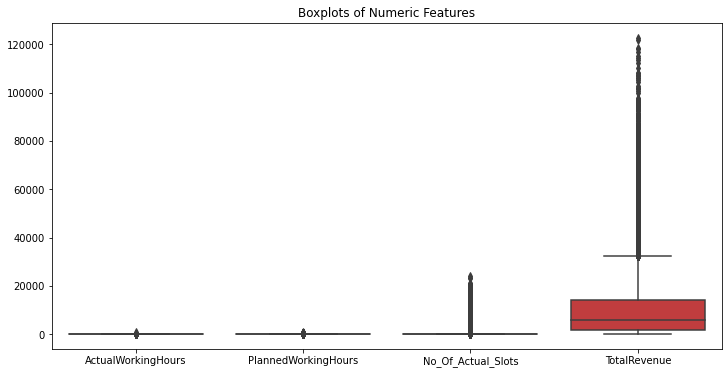

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=agg[["ActualWorkingHours","PlannedWorkingHours",
                      "No_Of_Actual_Slots","TotalRevenue"]])
plt.title("Boxplots of Numeric Features")
plt.show()


# Explanation — Scatterplot of Cases vs Revenue

## Purpose
Explore the **relationship between patient cases (slots)** and **revenue** to detect trends and highlight possible outliers.

## What the code does
- **Setup**
  - Creates a figure of size `(8,6)` for clarity.
- **Scatterplot**
  - X-axis: `No_Of_Actual_Slots` (number of cases).  
  - Y-axis: `TotalRevenue`.  
  - Uses `alpha=0.5` for semi-transparent points, helping visualize overlapping data.
- **Styling**
  - Adds title *"Cases vs Revenue (spot outliers)"*.
  - Displays the scatterplot with `plt.show()`.

## Why this matters
- Shows whether **more cases generally correlate with higher revenue**, validating operational efficiency.  
- Highlights **outlier points** (e.g., high revenue with low cases or vice versa), which may indicate data entry errors or exceptional events.  
- Supports further analysis on efficiency metrics such as revenue per case.

## Caveats
- Scatterplot does not account for **time trends**; clusters may represent different periods.  
- Outliers require business context before deciding whether to exclude or adjust.  
- Correlation does not imply causation — other factors (specialty type, hospital size) may influence the relationship.


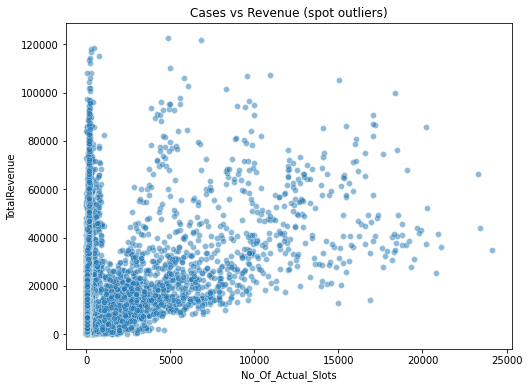

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=agg, x="No_Of_Actual_Slots", y="TotalRevenue", alpha=0.5)
plt.title("Cases vs Revenue (spot outliers)")
plt.show()


# Explanation — Outlier Clipping by Percentiles

## Purpose
Reduce the influence of **extreme outliers** in numeric features by capping values at the 1st and 99th percentiles.

## What the code does
- **Iterates through numeric columns**
  - `ActualWorkingHours`, `PlannedWorkingHours`, `No_Of_Actual_Slots`, `TotalRevenue`.
- **Calculate bounds**
  - Lower bound = 1st percentile (`quantile(0.01)`).
  - Upper bound = 99th percentile (`quantile(0.99)`).
- **Clip values**
  - Any values below the lower bound are replaced with the 1st percentile.  
  - Any values above the upper bound are replaced with the 99th percentile.
- **Update dataset**
  - Overwrites each column with the clipped version.

## Why this matters
- Prevents **extreme anomalies** from distorting statistical analysis or machine learning models.  
- Ensures that the majority of the data distribution is preserved while limiting the impact of outliers.  
- More robust than removing rows, as it retains all records.

## Caveats
- Percentile clipping is arbitrary (1%–99%); thresholds should be chosen based on **domain knowledge**.  
- May hide genuine extreme events that are valuable for business insights.  
- Does not address data entry errors (e.g., misplaced decimal points), which still need manual correction.


In [129]:
for col in ["ActualWorkingHours","PlannedWorkingHours","No_Of_Actual_Slots","TotalRevenue"]:
    lower = agg[col].quantile(0.01)
    upper = agg[col].quantile(0.99)
    agg[col] = agg[col].clip(lower, upper)


# Explanation — Filtering Extreme Hours

## Purpose
Remove records with **unrealistically high working hours** to maintain data validity and prevent distortions in analysis.

## What the code does
- **Filter Actual Working Hours**
  - Keeps only rows where `ActualWorkingHours ≤ 500`.
- **Filter Planned Working Hours**
  - Keeps only rows where `PlannedWorkingHours ≤ 500`.
- **Effect**
  - Excludes any entries with implausibly large values, which are likely due to data entry errors or anomalies.

## Why this matters
- Ensures that **outlier rows with inflated hours** do not bias statistical summaries, visualizations, or predictive models.  
- Improves overall data quality by enforcing a logical upper bound.

## Caveats
- The threshold of `500` is arbitrary; it should ideally be defined by **domain expertise** (e.g., maximum feasible staff hours per reporting unit).  
- Valid but extreme cases (e.g., aggregated across large hospitals or multiple shifts) may be incorrectly removed.  
- Filtering permanently drops rows, unlike clipping; use with caution if historical traceability is required.


In [130]:
agg = agg[agg["ActualWorkingHours"] <= 500]
agg = agg[agg["PlannedWorkingHours"] <= 500]


# Explanation — Distributions of Cases & Revenue

## Purpose
Visualize and assess the **distribution** of daily cases (`No_Of_Actual_Slots`) and daily revenue (`TotalRevenue`) to understand central tendency, variability, and skewness.

## What the code does
- **Histogram + KDE**
  - Creates a 1×2 subplot with histograms and Kernel Density Estimates (KDE):
    - Left: distribution of daily cases.
    - Right: distribution of daily revenue.
  - Uses 50 bins for detail and `kde=True` to overlay smooth density curves.
- **Titles**
  - Adds descriptive titles for both subplots.
- **Skewness check**
  - Calculates skewness for cases and revenue to measure distribution asymmetry:
    - Positive skew → long right tail (common in revenue data).
    - Negative skew → long left tail.

## Why this matters
- Highlights whether data is **normally distributed** or skewed, which influences statistical tests and modeling choices.  
- Skewed distributions may require transformations (e.g., log scaling) for fair analysis.  
- Provides a visual check for extreme values or heavy tails.

## Caveats
- Revenue often exhibits **heavy right skew** due to a few very high values.  
- KDE may smooth over multimodal distributions; validate with raw histograms as well.  
- Skewness alone does not capture all distribution characteristics (e.g., kurtosis).


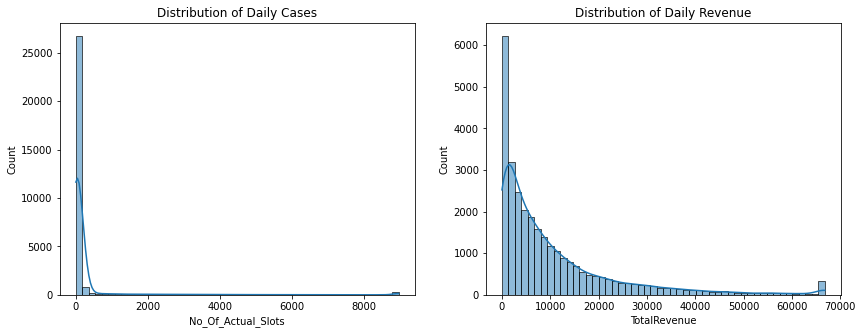

Skewness (Cases): 5.545401167408891
Skewness (Revenue): 2.121971457569029


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.histplot(agg["No_Of_Actual_Slots"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Daily Cases")

sns.histplot(agg["TotalRevenue"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Daily Revenue")
plt.show()

# Skewness check
print("Skewness (Cases):", agg["No_Of_Actual_Slots"].skew())
print("Skewness (Revenue):", agg["TotalRevenue"].skew())


# Explanation — Correlation & Pairwise Analysis

## Purpose
Examine **relationships among numeric variables** to detect linear correlations, dependencies, and potential multicollinearity.

## What the code does
- **Correlation heatmap**
  - Computes Pearson correlation across:
    - `ActualWorkingHours`
    - `PlannedWorkingHours`
    - `No_of_Clinic`
    - `No_Of_Actual_Slots`
    - `TotalRevenue`
  - Displays as a heatmap with values annotated (2 decimal places).
  - Uses `coolwarm` colormap for easy visual interpretation of positive vs negative correlations.
- **Pairplot**
  - Randomly samples 2000 rows (to avoid performance issues).
  - Creates pairwise scatterplots and histograms for the same numeric columns.
  - Allows visual inspection of distributions and relationships beyond linear correlation.

## Why this matters
- Heatmap provides a **quick overview of correlations**, useful for identifying strong predictors of revenue or redundant features.  
- Pairplot gives a **granular view of relationships**, including potential non-linear trends and clusters.  
- Together, these tools help validate assumptions before modeling (e.g., regression).

## Caveats
- Correlation measures **linear relationships only**; non-linear dependencies may be missed.  
- Pairplots can be computationally heavy on full datasets, hence sampling is necessary.  
- Correlation ≠ causation — strong relationships should be validated with domain expertise.


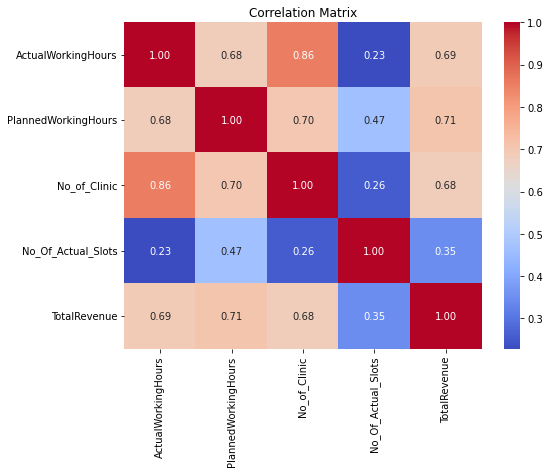

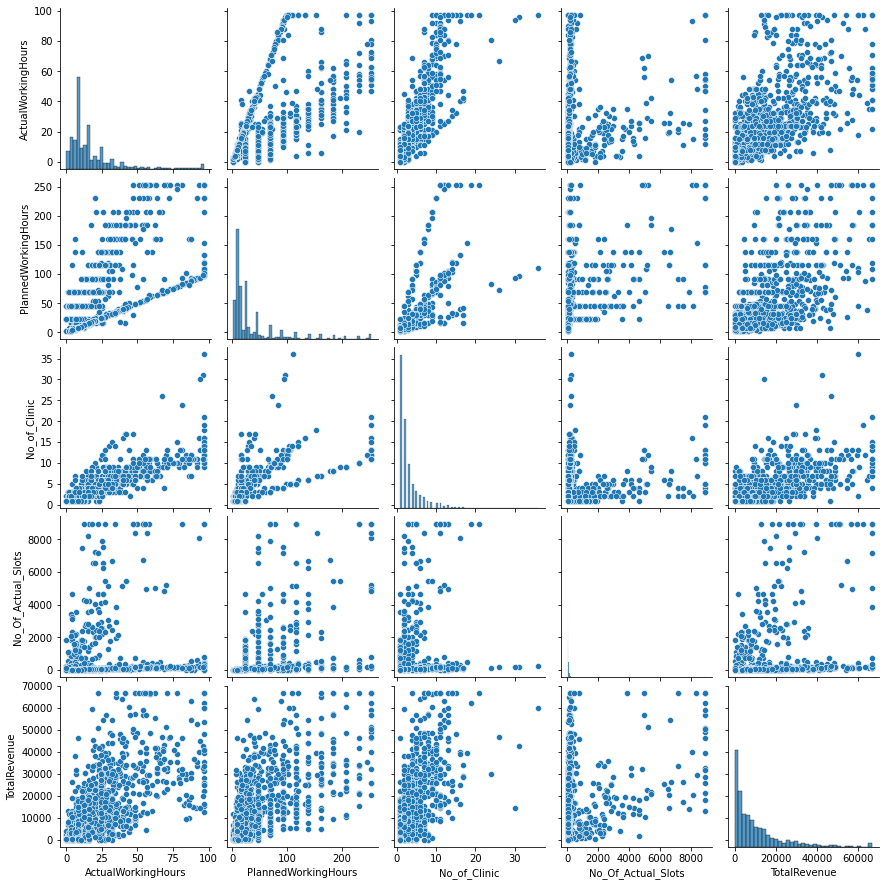

In [ ]:

plt.figure(figsize=(8,6))
sns.heatmap(
    agg[["ActualWorkingHours","PlannedWorkingHours","No_of_Clinic",
         "No_Of_Actual_Slots","TotalRevenue"]].corr(),
    annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

# Pairplot (sample 2000 points to avoid heavy plotting)
sns.pairplot(
    agg.sample(2000, random_state=42)[
        ["ActualWorkingHours","PlannedWorkingHours","No_of_Clinic",
         "No_Of_Actual_Slots","TotalRevenue"]
    ]
)
plt.show()


# Explanation — Correlation with Cases & Revenue

## Purpose
Quantify how **working hours and clinic activity** relate to both the number of cases (`No_Of_Actual_Slots`) and generated revenue (`TotalRevenue`).

## What the code does
- **Iterates over predictors**
  - Columns: `ActualWorkingHours`, `PlannedWorkingHours`, `No_of_Clinic`.
- **Calculates correlations**
  - `corr_cases` → correlation of each column with `No_Of_Actual_Slots`.
  - `corr_revenue` → correlation of each column with `TotalRevenue`.
- **Output**
  - Prints correlation coefficients (rounded to 3 decimals) for each metric.

## Why this matters
- Identifies which operational factors (hours, planned hours, or clinics) are **most strongly associated** with case volumes and revenue.  
- Helps prioritize features for predictive modeling and performance evaluation.  
- Clarifies whether efficiency improvements (e.g., increasing planned hours or clinics) align with higher outcomes.

## Caveats
- Correlation measures **linear strength only**; relationships may be non-linear.  
- Results are **sensitive to outliers**; extreme values can distort coefficients.  
- Correlation ≠ causation — strong relationships must be interpreted in business context.


In [ ]:
for col in ["ActualWorkingHours","PlannedWorkingHours","No_of_Clinic"]:
    corr_cases = agg[col].corr(agg["No_Of_Actual_Slots"])
    corr_revenue = agg[col].corr(agg["TotalRevenue"])
    print(f"{col} → Cases Corr: {corr_cases:.3f}, Revenue Corr: {corr_revenue:.3f}")


ActualWorkingHours → Cases Corr: 0.229, Revenue Corr: 0.692
PlannedWorkingHours → Cases Corr: 0.466, Revenue Corr: 0.708
No_of_Clinic → Cases Corr: 0.259, Revenue Corr: 0.683


# Explanation — Distribution of Specialties & Hospitals

## Purpose
Summarize the **frequency of records** across specialties and hospitals to identify the most represented groups in the dataset.

## What the code does
- **Specialty distribution**
  - Counts values in `Speciality_final`.
  - Selects the top 20 specialties.
  - Plots as a bar chart with count of records on the Y-axis.
  - Title: *"Top 20 Specialties by Observation Count"*.
- **Hospital distribution**
  - Counts values in `ShortName`.
  - Selects the top 20 hospitals.
  - Plots as a bar chart with record counts.
  - Title: *"Top 20 Hospitals by Observation Count"*.

## Why this matters
- Shows which **specialties and hospitals dominate** the dataset, guiding where insights are most reliable.  
- Identifies **imbalances** — some specialties/hospitals may have very few records, which can affect statistical significance or model training.  
- Helps focus analysis on the most relevant and data-rich specialties or hospitals.

## Caveats
- Only the **top 20** groups are shown; lower-frequency specialties/hospitals are not visualized.  
- Record count does not reflect actual patient volume or revenue contribution — further analysis is needed for those measures.  
- Rare specialties or hospitals may still hold important insights despite lower counts.


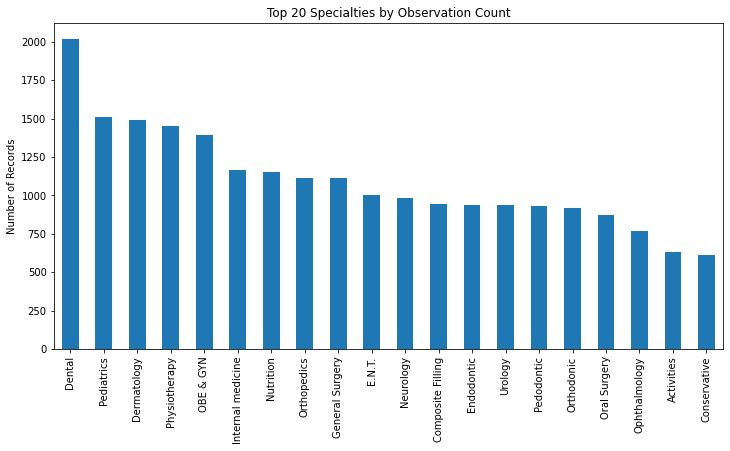

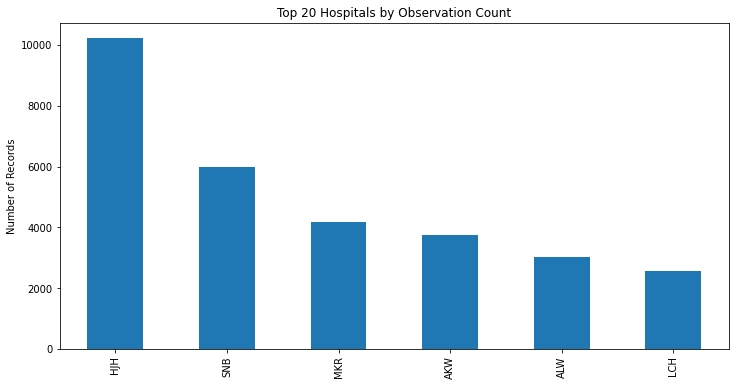

In [ ]:
plt.figure(figsize=(12,6))
(agg["Speciality_final"].value_counts().head(20)
    .plot(kind="bar"))
plt.title("Top 20 Specialties by Observation Count")
plt.ylabel("Number of Records")
plt.show()

plt.figure(figsize=(12,6))
(agg["ShortName"].value_counts().head(20)
    .plot(kind="bar"))
plt.title("Top 20 Hospitals by Observation Count")
plt.ylabel("Number of Records")
plt.show()


# Explanation — Revenue Trends Over Time

## Purpose
Visualize **temporal patterns** in hospital revenue to spot seasonal effects, growth, or anomalies across selected hospitals.

## What the code does
- **Select hospitals**
  - Takes the first three hospitals from the `ShortName` column (`unique()[:3]`) as sample cases.
- **Plot revenue trends**
  - For each hospital:
    - Filters its subset of records.
    - Groups by `Date` and sums `TotalRevenue`.
    - Plots a time-series line representing daily revenue trend.
- **Styling**
  - Sets figure size `(14,6)` for readability.
  - Adds title *"Revenue Trends Over Time (sample hospitals)"*.
  - Includes a legend labeling each hospital.

## Why this matters
- Reveals **temporal dynamics** of revenue, such as upward trends, seasonal dips, or sudden spikes.  
- Enables comparison between hospitals to assess consistency or variability in performance.  
- Provides early insight into demand fluctuations and operational efficiency.

## Caveats
- Only the **first 3 hospitals** are plotted — not necessarily the top performers or representative of all hospitals.  
- Revenue is aggregated **per day**; weekly or monthly aggregation may provide smoother trends.  
- Missing or irregular dates may create gaps or distortions in the plotted time series.


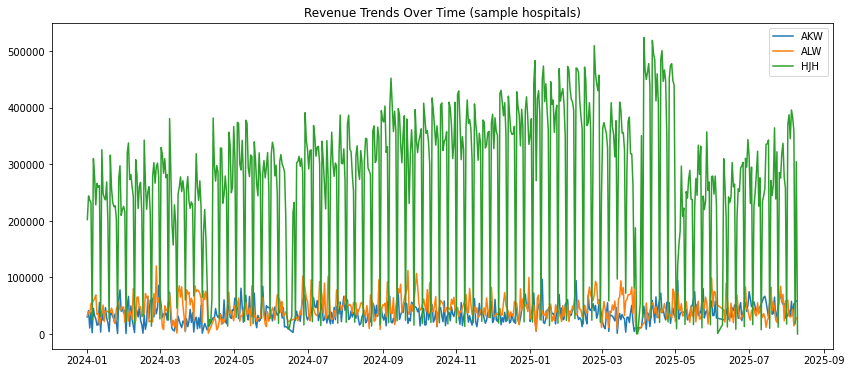

In [ ]:
plt.figure(figsize=(14,6))
sample_hosp = agg["ShortName"].unique()[:3]  # first 3 hospitals as example
for hosp in sample_hosp:
    subset = agg[agg["ShortName"] == hosp]
    plt.plot(subset.groupby("Date")["TotalRevenue"].sum(), label=hosp)
plt.title("Revenue Trends Over Time (sample hospitals)")
plt.legend()
plt.show()


# Explanation — Data Cleaning & Modeling Preparation

## Purpose
Prepare the aggregated dataset (`agg`) for **predictive modeling**, ensuring clean inputs, consistent features, and strategies to prevent data leakage.

## What the code does
1. **Configuration options**
   - `TREAT_ZERO_REVENUE_AS_MISSING`: interprets zero revenue as missing data (optional).
   - `APPLY_WINSORIZE_1_99`: caps values at 1st–99th percentiles to control extremes.
   - `APPLY_LOG_TARGETS`: applies `log1p` transform to targets for skewed data.
   - `EXCLUDE_CASES_WHEN_PREDICTING_REVENUE`: prevents leakage by not using case counts when modeling revenue.

2. **Column validation**
   - Confirms all required columns (`ShortName`, `Speciality_final`, `Date`, metrics, revenue) are present.
   - Ensures `Date` is parsed as datetime.

3. **Negative value handling**
   - Clips all negative values (`ActualWorkingHours`, `PlannedWorkingHours`, `No_Of_Actual_Slots`, `TotalRevenue`) to 0.

4. **Zero-revenue treatment (optional)**
   - Converts zeros to `NaN`, imputes with median per hospital-specialty, or global median.

5. **Winsorization**
   - Clips numeric features to 1st–99th percentile to reduce extreme outliers.

6. **Calendar features**
   - Extracts `Year`, `Month`, `DayOfWeek`, and `IsWeekend` for time-aware modeling.

7. **Feature and target definitions**
   - Numeric features: hours, clinics, calendar features.
   - Categorical features: `ShortName`, `Speciality_final`.
   - Targets: `No_Of_Actual_Slots` (cases) and `TotalRevenue` (revenue).
   - Revenue features exclude cases if leakage prevention is enabled.

8. **Target transformation**
   - Creates `y_cases_log1p` and `y_revenue_log1p` as log-transformed versions of targets.

9. **Train/validation split**
   - Defines a cutoff at the 80th percentile of `Date` for train/test separation.
   - Uses **GroupKFold** (5 splits) grouped by hospital for cross-validation.

10. **Summary printout**
    - Confirms cleaning/prep completion, row counts, feature sets, targets, and settings.

## Why this matters
- Creates a **robust dataset** for machine learning by handling missing values, outliers, and skewness.  
- Prevents **data leakage** by carefully selecting features.  
- Enriches data with calendar features for **temporal modeling**.  
- Sets a consistent structure for splitting and cross-validation.

## Caveats
- Winsorization thresholds (1–99%) and cutoffs (80% for time split) are arbitrary; may need adjustment.  
- Median imputation assumes stable distribution across hospitals/specialties.  
- Log transforms help with skewness but complicate interpretation of coefficients/predictions.  
- Feature selection should be revisited depending on the final modeling objective.


In [ ]:

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold

TREAT_ZERO_REVENUE_AS_MISSING = False   # set True if 0 means "not reported"
APPLY_WINSORIZE_1_99 = True             # cap extremes at 1st/99th pct
APPLY_LOG_TARGETS = True                # use log1p for skewed targets in modeling
EXCLUDE_CASES_WHEN_PREDICTING_REVENUE = True  # avoid potential leakage

# ---- 0) Assert required columns ----
req = {"ShortName","Speciality_final","Date",
       "ActualWorkingHours","PlannedWorkingHours","No_of_Clinic",
       "No_Of_Actual_Slots","TotalRevenue"}
missing_cols = req - set(agg.columns)
if missing_cols:
    raise ValueError(f"agg is missing columns: {missing_cols}")

# Ensure Date is datetime
agg["Date"] = pd.to_datetime(agg["Date"], errors="coerce")

# ---- 1) Remove invalid negatives (clip at 0) ----
for c in ["ActualWorkingHours","PlannedWorkingHours","No_Of_Actual_Slots","TotalRevenue"]:
    neg_ct = (agg[c] < 0).sum()
    if neg_ct:
        print(f"[fix] Clipping {neg_ct} negative values in {c} to 0")
    agg[c] = agg[c].clip(lower=0)

# ---- 2) Optional: treat zero-revenue as missing ----
if TREAT_ZERO_REVENUE_AS_MISSING:
    z_ct = (agg["TotalRevenue"] == 0).sum()
    if z_ct:
        print(f"[fix] Converting {z_ct} zero TotalRevenue rows to NaN (assumed missing)")
    agg.loc[agg["TotalRevenue"] == 0, "TotalRevenue"] = np.nan
    # simple impute with median per (hospital,specialty); fallback to global median
    med_local = agg.groupby(["ShortName","Speciality_final"])["TotalRevenue"].transform("median")
    agg["TotalRevenue"] = agg["TotalRevenue"].fillna(med_local)
    agg["TotalRevenue"] = agg["TotalRevenue"].fillna(agg["TotalRevenue"].median())

# ---- 3) Winsorize (1%–99%) to tame extremes ----
if APPLY_WINSORIZE_1_99:
    for c in ["ActualWorkingHours","PlannedWorkingHours","No_Of_Actual_Slots","TotalRevenue"]:
        lo, hi = agg[c].quantile([0.01, 0.99])
        before_hi = (agg[c] > hi).sum()
        before_lo = (agg[c] < lo).sum()
        if before_hi or before_lo:
            print(f"[fix] Winsorizing {c}: {before_lo} below {lo:.2f}, {before_hi} above {hi:.2f}")
        agg[c] = agg[c].clip(lower=lo, upper=hi)

# ---- 4) Calendar features (for modeling) ----
agg["Year"]      = agg["Date"].dt.year
agg["Month"]     = agg["Date"].dt.month
agg["DayOfWeek"] = agg["Date"].dt.dayofweek
agg["IsWeekend"] = agg["DayOfWeek"].isin([4,5]).astype(int)  # adjust if needed

# ---- 5) Define features/targets with leakage control ----
# Base feature set
NUM_FEATURES = ["ActualWorkingHours","PlannedWorkingHours","No_of_Clinic",
                "Year","Month","DayOfWeek","IsWeekend"]
CAT_FEATURES = ["ShortName","Speciality_final"]

# Targets
TARGET_CASES   = "No_Of_Actual_Slots"
TARGET_REVENUE = "TotalRevenue"

# If you predict revenue and cannot know cases in advance, exclude cases from features:
if EXCLUDE_CASES_WHEN_PREDICTING_REVENUE:
    FEATURES_FOR_REVENUE = NUM_FEATURES + CAT_FEATURES
else:
    FEATURES_FOR_REVENUE = NUM_FEATURES + [TARGET_CASES] + CAT_FEATURES

FEATURES_FOR_CASES = NUM_FEATURES + CAT_FEATURES

# ---- 6) Optional log transform targets (for modeling stage) ----
# Create columns for transformed targets (do not overwrite originals)
if APPLY_LOG_TARGETS:
    agg["y_cases_log1p"]   = np.log1p(agg[TARGET_CASES])
    agg["y_revenue_log1p"] = np.log1p(agg[TARGET_REVENUE])
else:
    agg["y_cases_log1p"]   = agg[TARGET_CASES]
    agg["y_revenue_log1p"] = agg[TARGET_REVENUE]

# ---- 7) Train/validation split strategy & GroupKFold (by hospital) ----
# Example time-based cutoff: last 20% of dates as test
cutoff = agg["Date"].quantile(0.8)
train_idx = agg["Date"] <= cutoff
test_idx  = agg["Date"]  > cutoff

groups = agg["ShortName"]  # group by hospital for CV
gkf = GroupKFold(n_splits=5)

print("\n[summary] Cleaning & prep completed.")
print("Rows:", len(agg))
print("Train rows:", train_idx.sum(), " | Test rows:", test_idx.sum())
print("Features (revenue):", FEATURES_FOR_REVENUE)
print("Features (cases):  ", FEATURES_FOR_CASES)
print("Targets:           ", [TARGET_CASES, TARGET_REVENUE])
print("Log targets used:  ", APPLY_LOG_TARGETS)
print("Leakage control (exclude cases from revenue):", EXCLUDE_CASES_WHEN_PREDICTING_REVENUE)


[fix] Winsorizing No_Of_Actual_Slots: 0 below 1.00, 298 above 8944.44
[fix] Winsorizing TotalRevenue: 0 below 0.00, 298 above 66771.04

[summary] Cleaning & prep completed.
Rows: 29718
Train rows: 23802  | Test rows: 5916
Features (revenue): ['ActualWorkingHours', 'PlannedWorkingHours', 'No_of_Clinic', 'Year', 'Month', 'DayOfWeek', 'IsWeekend', 'ShortName', 'Speciality_final']
Features (cases):   ['ActualWorkingHours', 'PlannedWorkingHours', 'No_of_Clinic', 'Year', 'Month', 'DayOfWeek', 'IsWeekend', 'ShortName', 'Speciality_final']
Targets:            ['No_Of_Actual_Slots', 'TotalRevenue']
Log targets used:   True
Leakage control (exclude cases from revenue): True


# Explanation — Distributions of Cleaned Cases & Revenue

## Purpose
Visualize the **cleaned distributions** of daily cases and revenue to confirm improvements in data quality and evaluate remaining skewness after preprocessing.

## What the code does
- **Histogram + KDE**
  - Creates side-by-side plots (1×2 layout):
    - Left: `No_Of_Actual_Slots` (daily cases).
    - Right: `TotalRevenue` (daily revenue).
  - Uses 50 bins and overlays Kernel Density Estimate (KDE) for smooth distribution curves.
- **Titles**
  - Adds descriptive titles to distinguish cleaned distributions.
- **Skewness check**
  - Prints skewness values for cases and revenue:
    - Positive skew → long right tail.
    - Negative skew → long left tail.
    - Near zero → roughly symmetric distribution.

## Why this matters
- Confirms whether earlier **clipping, winsorization, and filtering** steps reduced the impact of extreme values.  
- Skewness values provide a quantitative check for whether **log transformations** are still needed in modeling.  
- Validates the success of cleaning in producing a dataset better suited for statistical analysis.

## Caveats
- KDE smoothing may obscure multimodal patterns; histogram shape should also be considered.  
- Even after cleaning, revenue typically remains **right-skewed**, which may require log transforms for fair modeling.  
- Skewness metric is sensitive to outliers; minor anomalies may still influence results.


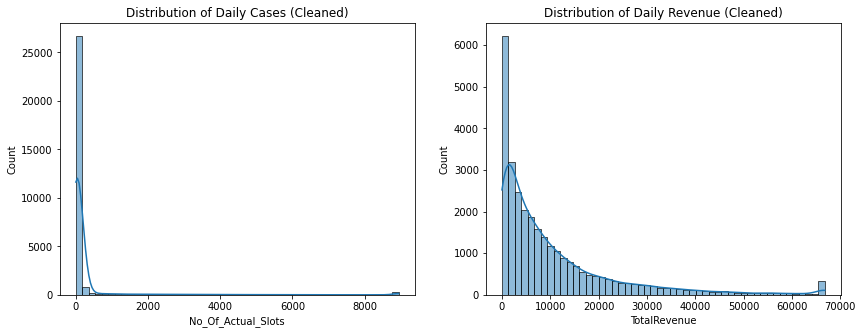

Skewness (Cases): 5.543785214633449
Skewness (Revenue): 2.121911852699024


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.histplot(agg["No_Of_Actual_Slots"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Daily Cases (Cleaned)")

sns.histplot(agg["TotalRevenue"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Daily Revenue (Cleaned)")
plt.show()

# Skewness check
print("Skewness (Cases):", agg["No_Of_Actual_Slots"].skew())
print("Skewness (Revenue):", agg["TotalRevenue"].skew())


# Explanation — Correlation Matrix (Cleaned)

## Purpose
Re-evaluate **linear relationships** among cleaned numeric variables to confirm whether outlier handling and preprocessing improved data consistency.

## What the code does
- **Correlation calculation**
  - Computes Pearson correlation across:
    - `ActualWorkingHours`
    - `PlannedWorkingHours`
    - `No_of_Clinic`
    - `No_Of_Actual_Slots`
    - `TotalRevenue`
- **Heatmap visualization**
  - Annotates correlation values (2 decimals).
  - Uses `coolwarm` colormap to highlight strength and direction:
    - Positive correlation (red tones).
    - Negative correlation (blue tones).
- **Styling**
  - Sets figure size `(8,6)`.
  - Adds title *"Correlation Matrix (Cleaned)"*.

## Why this matters
- Validates whether **expected relationships** hold after cleaning (e.g., more working hours should generally correlate with more cases/revenue).  
- Detects **multicollinearity** between predictors, which may affect regression or ML models.  
- Helps refine **feature selection** by highlighting the strongest explanatory variables for cases and revenue.

## Caveats
- Correlation captures **linear dependence only**; non-linear relationships may be missed.  
- Results may still be influenced by residual skewness despite cleaning.  
- High correlation between predictors can reduce interpretability in models without regularization.


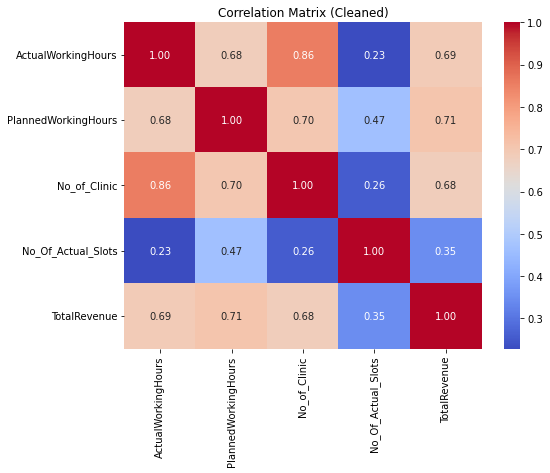

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    agg[["ActualWorkingHours","PlannedWorkingHours","No_of_Clinic",
         "No_Of_Actual_Slots","TotalRevenue"]].corr(),
    annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Correlation Matrix (Cleaned)")
plt.show()


# Explanation — Scatterplots of Cleaned Data

## Purpose
Visualize the **relationships between cases, working hours, and revenue** after cleaning to confirm logical trends and spot residual anomalies.

## What the code does
- **Cases vs Revenue**
  - Scatterplot with:
    - X-axis: `No_Of_Actual_Slots` (cases).
    - Y-axis: `TotalRevenue`.
  - Uses `alpha=0.5` transparency to reduce overplotting.
  - Title: *"Cases vs Revenue (Cleaned)"*.
- **Working Hours vs Revenue**
  - Scatterplot with:
    - X-axis: `ActualWorkingHours`.
    - Y-axis: `TotalRevenue`.
  - Same transparency and styling.
  - Title: *"Working Hours vs Revenue (Cleaned)"*.

## Why this matters
- Confirms whether the **expected positive relationship** between workload (cases or hours) and revenue holds true after data cleaning.  
- Highlights any **remaining outliers** (e.g., high revenue with low cases or hours) that may warrant investigation.  
- Provides insight into **operational efficiency**: how strongly cases and working hours explain revenue variation.

## Caveats
- Scatterplots show **correlation**, not causation; other factors (e.g., specialty type, hospital size) may drive revenue differences.  
- Density of overlapping points may hide patterns — consider log scaling or hexbin plots for more clarity in dense regions.  
- Residual skew in revenue may still compress the scale; transformations (e.g., log revenue) can make relationships clearer.


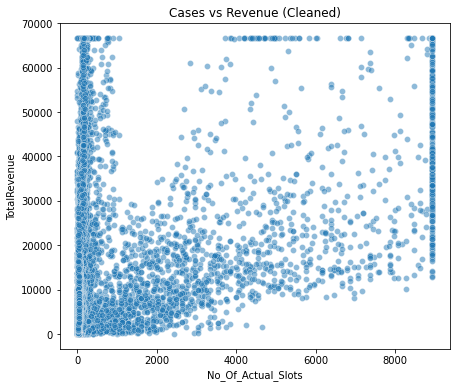

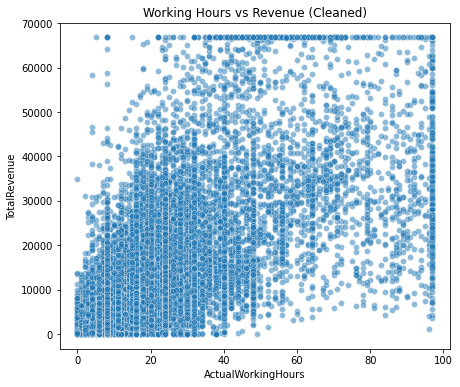

In [ ]:

plt.figure(figsize=(7,6))
sns.scatterplot(data=agg, x="No_Of_Actual_Slots", y="TotalRevenue", alpha=0.5)
plt.title("Cases vs Revenue (Cleaned)")
plt.show()

plt.figure(figsize=(7,6))
sns.scatterplot(data=agg, x="ActualWorkingHours", y="TotalRevenue", alpha=0.5)
plt.title("Working Hours vs Revenue (Cleaned)")
plt.show()


# Explanation — Distribution of Specialties & Hospitals (Cleaned)

## Purpose
Show the **most frequently occurring specialties and hospitals** in the cleaned dataset, helping to identify dominant groups for further analysis.

## What the code does
- **Top specialties**
  - Counts values in `Speciality_final`.
  - Selects the top 15 specialties.
  - Displays results as a bar chart with record counts on the Y-axis.
  - Title: *"Top 15 Specialties by Observation Count (Cleaned)"*.
- **Top hospitals**
  - Counts values in `ShortName`.
  - Selects the top 15 hospitals.
  - Displays results as a bar chart with record counts.
  - Title: *"Top 15 Hospitals by Observation Count (Cleaned)"*.

## Why this matters
- Highlights which **specialties and hospitals dominate** the dataset, guiding where insights and models will be most reliable.  
- Reveals **imbalances in representation**, showing that some specialties or hospitals may have limited data.  
- Helps prioritize focus areas for analysis, reporting, or modeling.

## Caveats
- Visualization is limited to the **top 15** groups, excluding rarer specialties and hospitals.  
- High observation counts do not necessarily equal higher patient volume or revenue — further analysis is required to measure actual impact.  
- Rare categories may still hold valuable insights despite being less frequent in the dataset.


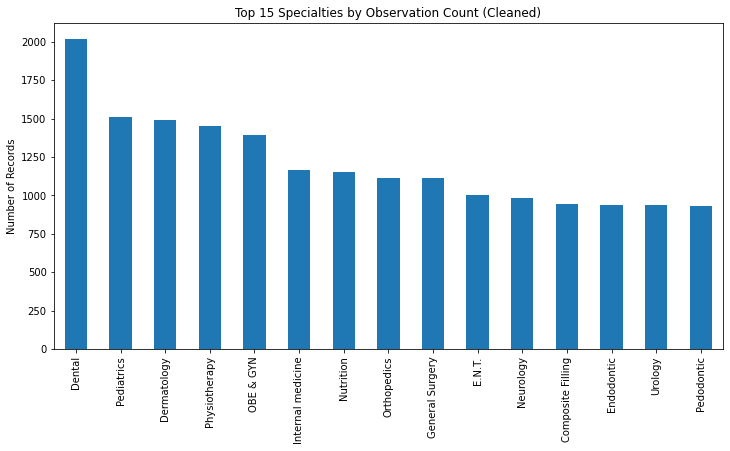

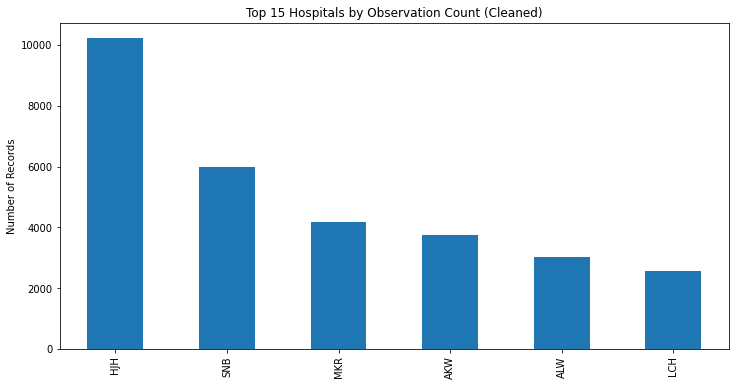

In [ ]:

# Top specialties
plt.figure(figsize=(12,6))
(agg["Speciality_final"].value_counts().head(15)
    .plot(kind="bar"))
plt.title("Top 15 Specialties by Observation Count (Cleaned)")
plt.ylabel("Number of Records")
plt.show()

# Top hospitals
plt.figure(figsize=(12,6))
(agg["ShortName"].value_counts().head(15)
    .plot(kind="bar"))
plt.title("Top 15 Hospitals by Observation Count (Cleaned)")
plt.ylabel("Number of Records")
plt.show()


# Explanation — Revenue Trends Over Time (Cleaned)

## Purpose
Analyze **temporal revenue patterns** across sample hospitals to understand seasonality, growth trends, or anomalies in the cleaned dataset.

## What the code does
- **Hospital selection**
  - Takes the first 3 hospitals from `ShortName` as sample cases for visualization.
- **Trend plotting**
  - For each hospital:
    - Filters its subset of records.
    - Groups by `Date` and sums `TotalRevenue`.
    - Plots a line showing revenue progression over time.
- **Styling**
  - Sets figure size `(14,6)` for clarity.
  - Adds title *"Revenue Trends Over Time (Sample Hospitals, Cleaned)"*.
  - Adds a legend to distinguish hospitals.

## Why this matters
- Reveals **revenue seasonality** (e.g., monthly or yearly cycles).  
- Identifies **growth or decline patterns** within individual hospitals.  
- Helps compare hospitals’ **stability and variability** in revenue performance.  
- Provides a foundation for time-series forecasting or anomaly detection.

## Caveats
- Only the **first 3 hospitals** are shown; not necessarily the largest or most representative.  
- Trends are shown **daily**; weekly or monthly aggregation might yield clearer patterns.  
- Data gaps or irregular reporting may affect the smoothness of the trend lines.


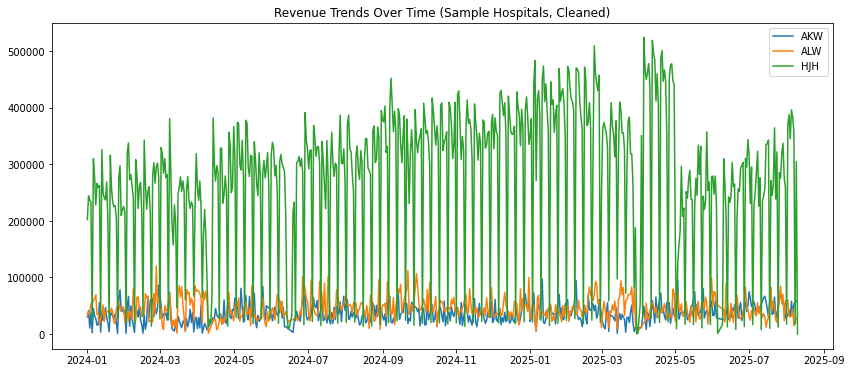

In [ ]:

plt.figure(figsize=(14,6))
for hosp in agg["ShortName"].unique()[:3]:   # show 3 sample hospitals
    subset = agg[agg["ShortName"] == hosp]
    plt.plot(subset.groupby("Date")["TotalRevenue"].sum(), label=hosp)
plt.title("Revenue Trends Over Time (Sample Hospitals, Cleaned)")
plt.legend()
plt.show()


# Explanation — Data Validation & Robust Metrics

## Purpose
Check for **data inconsistencies**, validate correlations, and compute a robust measure of **revenue per case**.

## What the code does
1. **Misalignment check**
   - Filters rows where `No_Of_Actual_Slots == 0` but `TotalRevenue > 1000`.
   - Counts such anomalies and groups them by `ShortName` (hospital) to identify where they occur most.

2. **Correlation (without capped points)**
   - Removes extreme capped points (`No_Of_Actual_Slots < 8944` and `TotalRevenue < 66771`).
   - Computes:
     - **Pearson correlation** → linear association between cases and revenue.
     - **Spearman correlation** → rank-based correlation, robust to skew and outliers.

3. **Revenue per case**
   - Creates a copy of the dataset, keeping only rows with `No_Of_Actual_Slots > 0`.
   - Computes `rev_per_case = TotalRevenue / No_Of_Actual_Slots`.
   - Prints descriptive statistics (count, mean, quartiles, min, max).

## Why this matters
- **Misalignment check** detects logical inconsistencies (e.g., revenue recorded with zero cases), which may point to reporting or data entry errors.  
- **Correlation metrics** validate the expected positive link between cases and revenue, while accounting for extreme values.  
- **Revenue per case** provides a robust measure of efficiency and profitability across hospitals and specialties.

## Caveats
- The `>1000` revenue threshold for misalignment is arbitrary and should be reviewed with dom


In [ ]:
# 1) How many rows look misaligned?
mis = agg[(agg["No_Of_Actual_Slots"]==0) & (agg["TotalRevenue"]>1000)]
print("Zero cases but revenue>1k:", len(mis))
print(mis.groupby("ShortName").size().sort_values(ascending=False).head(10))

# 2) Correlations without capped points
uncapped = agg[(agg["No_Of_Actual_Slots"]<8944) & (agg["TotalRevenue"]<66771)]
print("Pearson:", uncapped["No_Of_Actual_Slots"].corr(uncapped["TotalRevenue"]))
print("Spearman:", uncapped["No_Of_Actual_Slots"].corr(uncapped["TotalRevenue"], method="spearman"))

# 3) Revenue per case
tmp = agg.copy()
tmp = tmp[tmp["No_Of_Actual_Slots"]>0]
tmp["rev_per_case"] = tmp["TotalRevenue"]/tmp["No_Of_Actual_Slots"]
print(tmp["rev_per_case"].describe())


Zero cases but revenue>1k: 0
Series([], dtype: int64)
Pearson: 0.21306224608305124
Spearman: 0.6815066116910757
count    29718.000000
mean       258.357479
std       1313.607791
min          0.000000
25%         52.500000
50%        156.945692
75%        281.750815
max      66771.041126
Name: rev_per_case, dtype: float64


# Explanation — EDA Function per Hospital & Specialty

## Purpose
Automate **exploratory data analysis (EDA)** for each hospital, focusing on its top specialty (or subspecialty) by revenue, and generate visual and statistical insights.

## What the code does
- **Subset by hospital**
  - Filters data for a single hospital (`ShortName`).
  - Counts unique specialties (`Speciality_final`).
- **Specialty selection**
  - If multiple specialties: picks the **top revenue specialty**.
  - If only one specialty: falls back to `SubSpeciality_mode` if available; otherwise keeps the single specialty.
- **Summary info**
  - Prints record count and date range for the selected hospital-specialty.
- **Visualizations**
  1. **Distributions** → Histograms + KDE for cases (`No_Of_Actual_Slots`) and revenue (`TotalRevenue`).
  2. **Correlation heatmap** → Correlation across workload and revenue variables.
  3. **Scatterplots** → Cases vs revenue, and hours vs revenue.
  4. **Time trends** → Line charts showing daily revenue and cases progression.
- **Loop through hospitals**
  - Runs the function for every hospital in the dataset (`agg["ShortName"].unique()`).

## Why this matters
- Provides **hospital-level insights**, highlighting which specialty drives most revenue.  
- Helps compare **workload vs outcomes** (cases, hours, revenue) across hospitals.  
- Supports identification of **patterns and anomalies** over time at both specialty and hospital level.  
- Automates repetitive EDA steps, ensuring consistent analysis across all hospitals.

## Caveats
- Uses only the **top specialty by revenue**; smaller but important specialties may be overlooked.  
- For single-specialty hospitals, relying on subspecialty assumes consistent and valid subspecialty reporting.  
- Plotting all hospitals in sequence may generate many charts, making results harder to review without filtering.



=== EDA for Hospital: AKW | Specialty: Dental ===
Rows: 500
Date range: 2024-01-01 00:00:00 → 2025-08-09 00:00:00


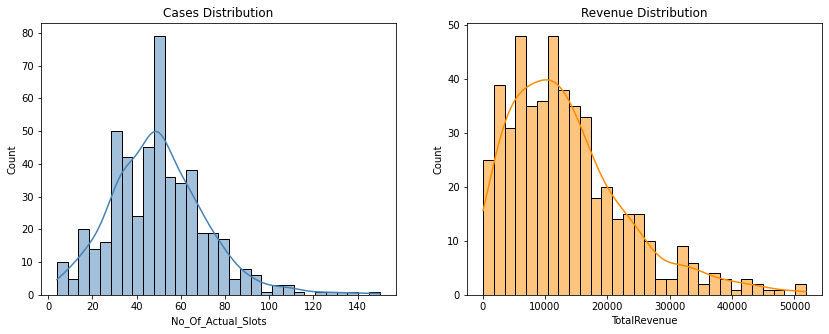

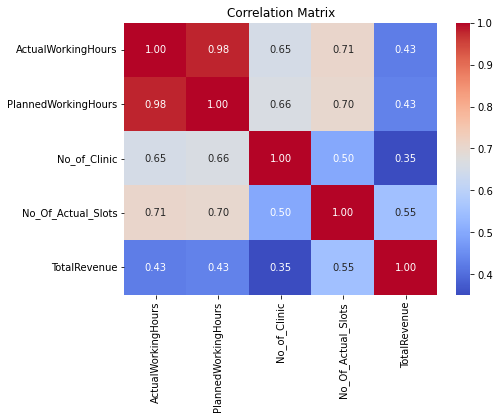

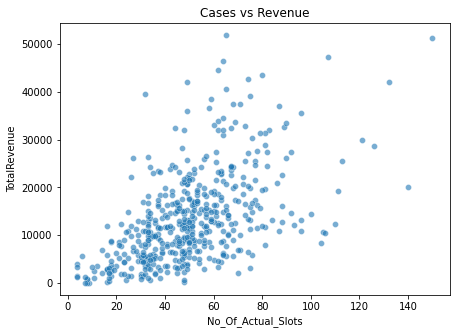

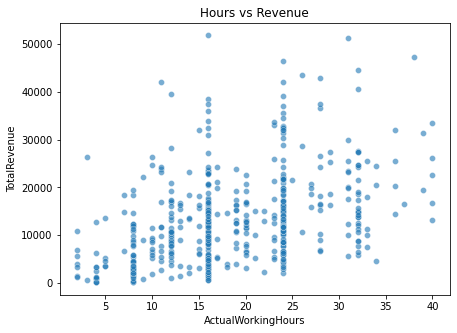

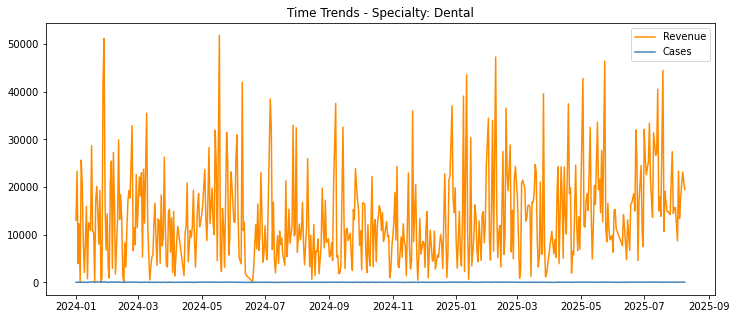


=== EDA for Hospital: ALW | Specialty: Dermatology ===
Rows: 496
Date range: 2024-01-01 00:00:00 → 2025-08-09 00:00:00


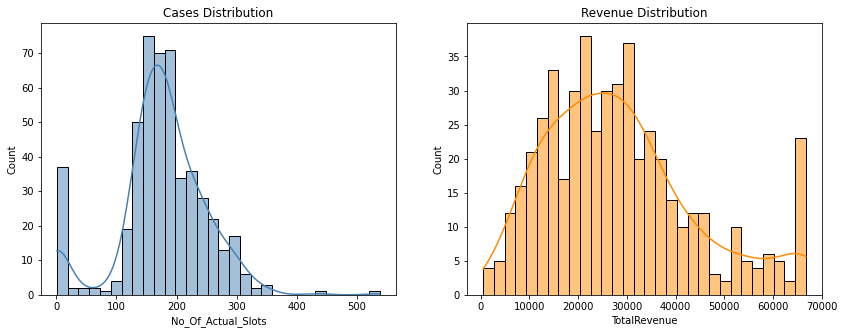

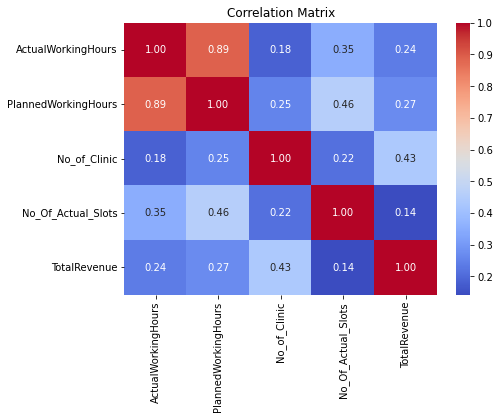

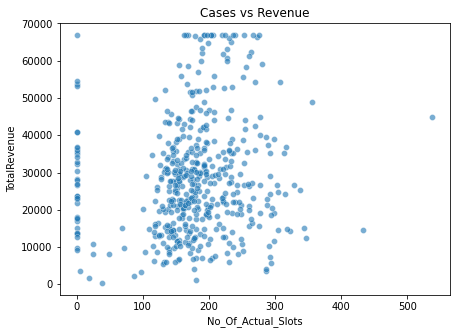

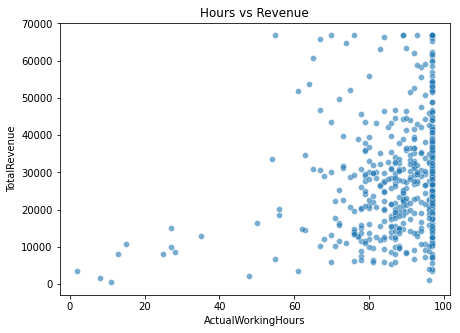

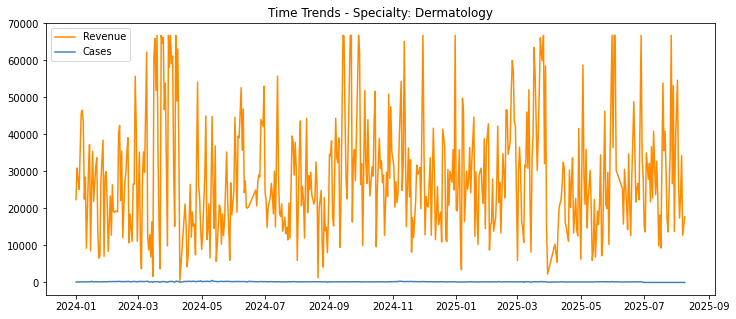


=== EDA for Hospital: HJH | Specialty: Internal medicine ===
Rows: 578
Date range: 2024-01-01 00:00:00 → 2025-08-09 00:00:00


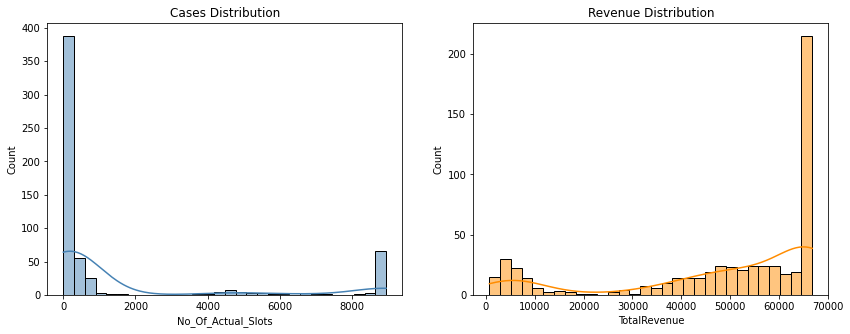

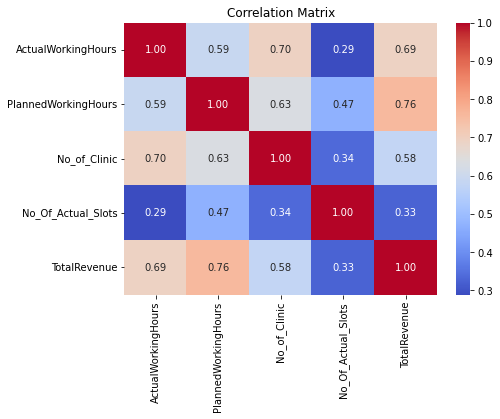

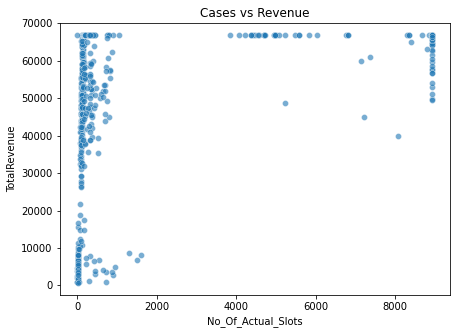

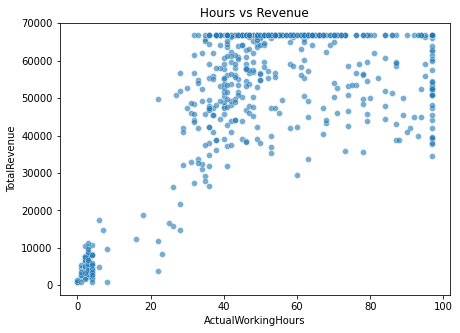

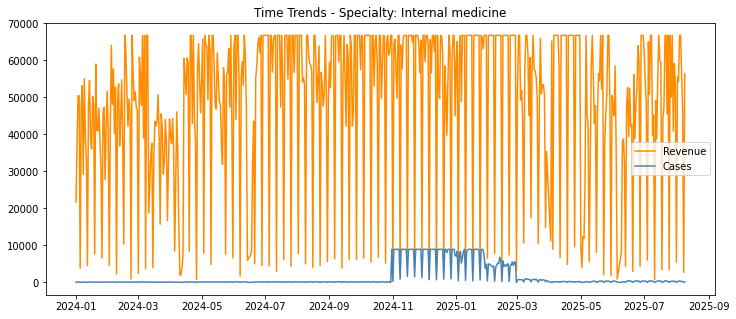


=== EDA for Hospital: LCH | Specialty: Orthodonic ===
Rows: 439
Date range: 2024-01-01 00:00:00 → 2025-05-31 00:00:00


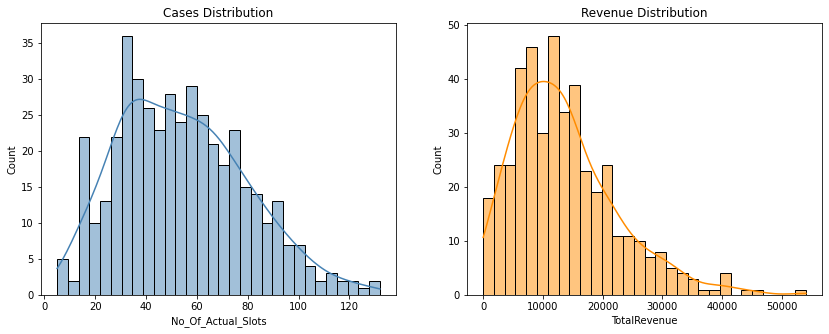

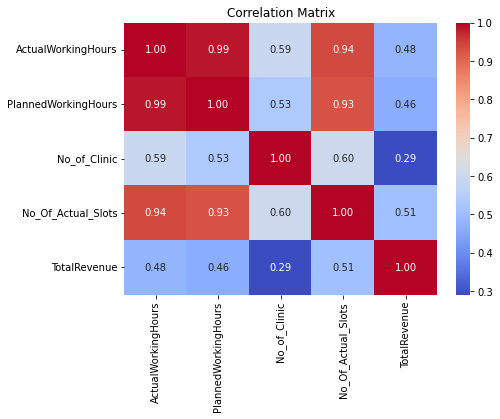

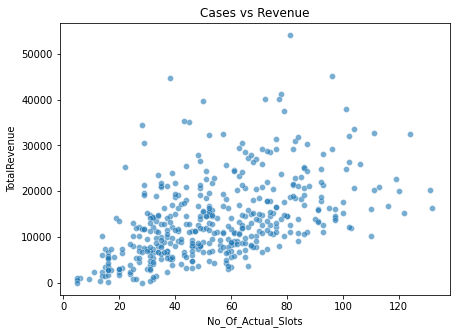

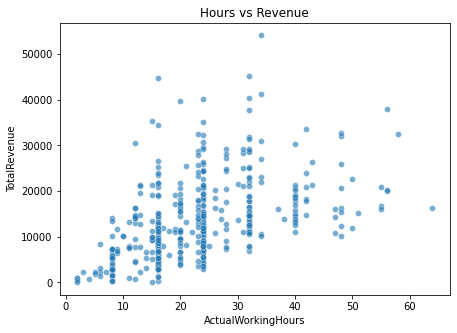

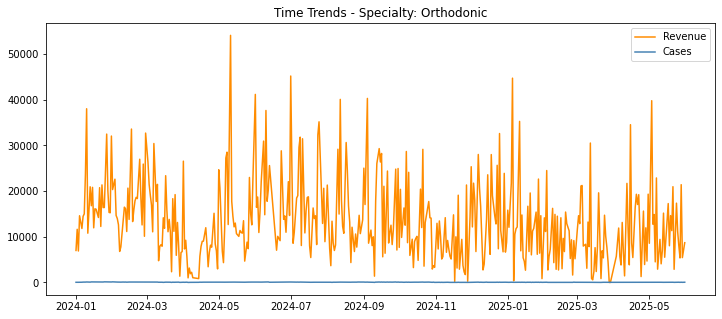


=== EDA for Hospital: MKR | Specialty: Endodontic ===
Rows: 501
Date range: 2024-01-01 00:00:00 → 2025-08-09 00:00:00


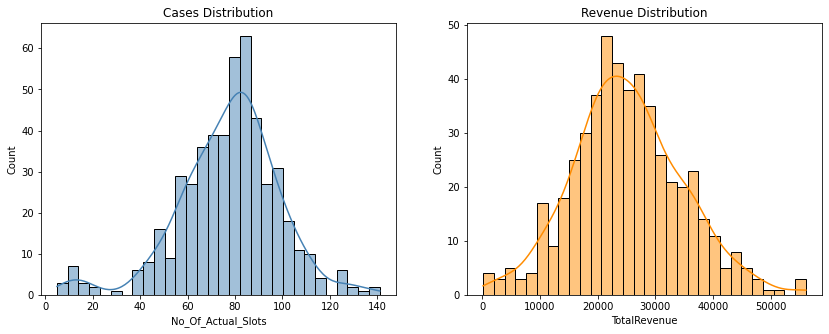

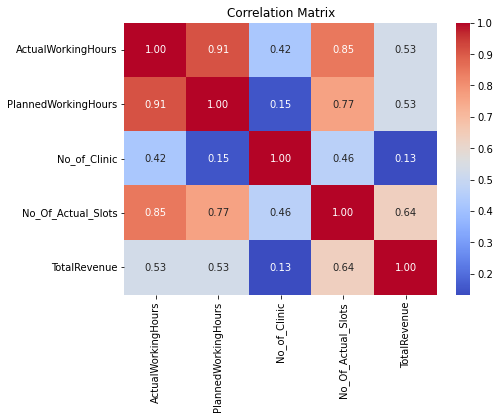

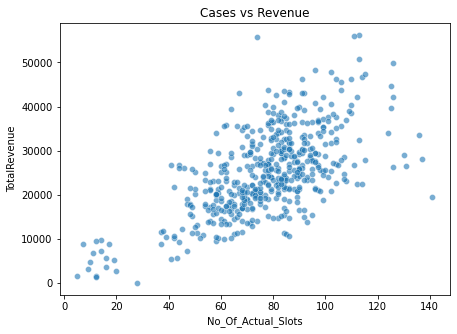

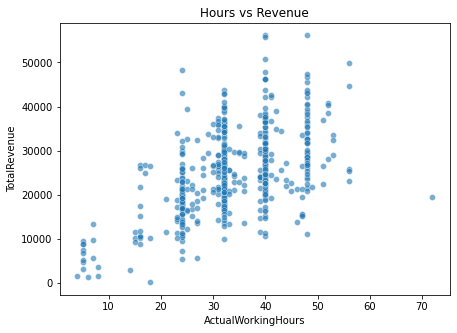

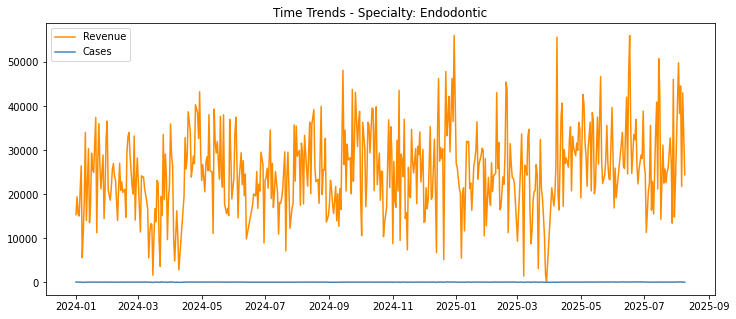


=== EDA for Hospital: SNB | Specialty: Dental ===
Rows: 560
Date range: 2024-01-01 00:00:00 → 2025-08-09 00:00:00


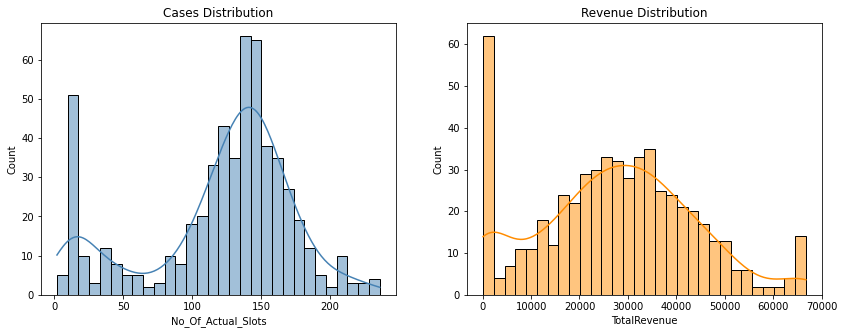

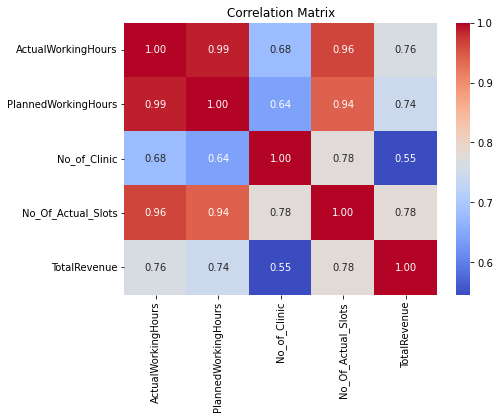

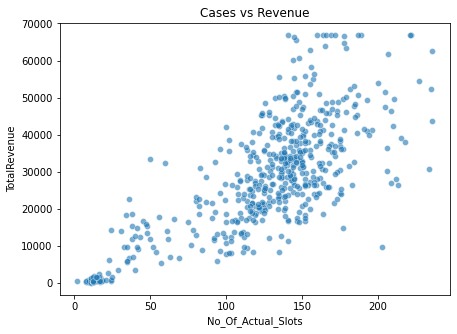

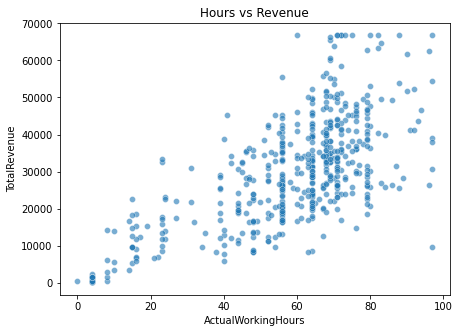

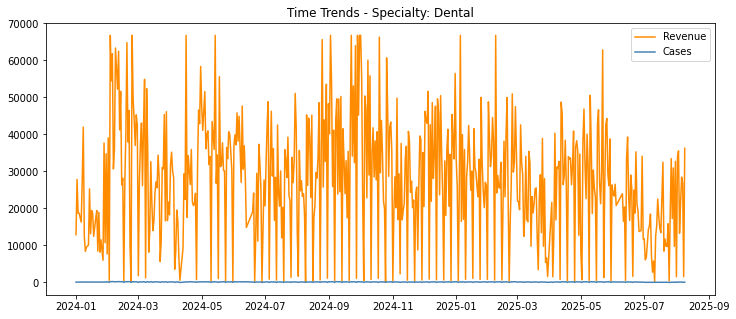

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

def eda_top_speciality(df, hosp):
    subset = df[df["ShortName"] == hosp]
    if subset.empty:
        print(f"No data for {hosp}")
        return
    
    # --- Check how many specialties the hospital has ---
    n_specs = subset["Speciality_final"].nunique()
    
    if n_specs > 1:
        # pick top performing specialty by TotalRevenue
        top_spec = (subset.groupby("Speciality_final")["TotalRevenue"]
                          .sum()
                          .sort_values(ascending=False)
                          .index[0])
        spec_subset = subset[subset["Speciality_final"] == top_spec]
        spec_label = f"Specialty: {top_spec}"
    else:
        # hospital has only 1 specialty → use SubSpeciality instead
        if "SubSpeciality_mode" in subset.columns:
            top_subspec = (subset.groupby("SubSpeciality_mode")["TotalRevenue"]
                                   .sum()
                                   .sort_values(ascending=False)
                                   .index[0])
            spec_subset = subset[subset["SubSpeciality_mode"] == top_subspec]
            spec_label = f"SubSpecialty: {top_subspec}"
        else:
            # fallback: just use the single specialty
            top_spec = subset["Speciality_final"].iloc[0]
            spec_subset = subset
            spec_label = f"Specialty: {top_spec}"
    
    print(f"\n=== EDA for Hospital: {hosp} | {spec_label} ===")
    print("Rows:", len(spec_subset))
    print("Date range:", spec_subset["Date"].min(), "→", spec_subset["Date"].max())
    
    # --- Distributions ---
    fig, axes = plt.subplots(1,2, figsize=(14,5))
    sns.histplot(spec_subset["No_Of_Actual_Slots"], bins=30, kde=True, ax=axes[0], color="steelblue")
    axes[0].set_title("Cases Distribution")
    sns.histplot(spec_subset["TotalRevenue"], bins=30, kde=True, ax=axes[1], color="darkorange")
    axes[1].set_title("Revenue Distribution")
    plt.show()
    
    # --- Correlation Heatmap ---
    plt.figure(figsize=(7,5))
    sns.heatmap(spec_subset[["ActualWorkingHours","PlannedWorkingHours","No_of_Clinic",
                             "No_Of_Actual_Slots","TotalRevenue"]].corr(),
                annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()
    
    # --- Scatterplots ---
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=spec_subset, x="No_Of_Actual_Slots", y="TotalRevenue", alpha=0.6)
    plt.title("Cases vs Revenue")
    plt.show()
    
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=spec_subset, x="ActualWorkingHours", y="TotalRevenue", alpha=0.6)
    plt.title("Hours vs Revenue")
    plt.show()
    
    # --- Time Trends ---
    plt.figure(figsize=(12,5))
    plt.plot(spec_subset.groupby("Date")["TotalRevenue"].sum(), label="Revenue", color="darkorange")
    plt.plot(spec_subset.groupby("Date")["No_Of_Actual_Slots"].sum(), label="Cases", color="steelblue")
    plt.legend()
    plt.title(f"Time Trends - {spec_label}")
    plt.show()


# ------------------------
# Run for all hospitals
# ------------------------
for hosp in agg["ShortName"].unique():
    eda_top_speciality(agg, hosp)


# Explanation — Per-Hospital & Specialty Modeling

## Purpose
Build **predictive models** for both cases and revenue at the hospital–specialty level, using Gradient Boosting regression with multi-output prediction.

## What the code does
1. **Configuration**
   - `MIN_ROWS_TRAIN = 60`: skips very small specialties.
   - `TEST_FRACTION = 0.2`: last 20% of records (by date) used as test set.
   - `num_cols`: numeric features including hours, clinics, and calendar features.

2. **Hospital loop**
   - Iterates over each hospital (`ShortName`).
   - Decides modeling unit:
     - If >1 specialties → use `Speciality_final`.
     - Else if >1 subspecialties → use `SubSpeciality_mode`.
     - Else → fallback to single specialty.

3. **Unit loop**
   - For each hospital–unit pair:
     - Skips if not enough rows (`< MIN_ROWS_TRAIN`).
     - Splits into train/test by date quantile (80/20).
     - Defines features (`num_cols`) and targets:
       - `No_Of_Actual_Slots` (cases).
       - `TotalRevenue` (revenue).

4. **Pipeline**
   - Preprocessing:
     - `SimpleImputer` (median).
     - `StandardScaler`.
   - Estimator:
     - `GradientBoostingRegressor` wrapped in `MultiOutputRegressor` for simultaneous prediction of cases and revenue.
   - Fits the pipeline on training data.

5. **Evaluation**
   - Predicts on test set.
   - Computes errors:
     - RMSE & MAE for cases.
     - RMSE & MAE for revenue.
   - Prints results per unit.

6. **Storage**
   - Saves trained model in `spec_models`.
   - Collects metrics in `spec_metrics`.
   - Stores predictions in `spec_predictions` (with true vs predicted values).

7. **Summary**
   - Compiles results into:
     - `metrics_df`: performance metrics table.
     - `preds_df`: detailed predictions.
   - Prints number of hospitals and units modeled.

## Why this matters
- Provides **hospital- and specialty-level forecasting models** for cases and revenue.  
- Validates model accuracy with **time-aware splits** (avoids leakage).  
- Produces both performance metrics and detailed predictions for monitoring and further analysis.

## Caveats
- Small specialties (<60 rows) are skipped, which may exclude rare but important units.  
- Only numeric features are used; categorical features (hospital, specialty) are implicitly fixed by modeling per unit.  
- Gradient Boosting is strong but not optimized here; hyperparameter tuning may further improve performance.  
- Time split assumes chronological consistency; irregular reporting dates may affect train/test separation.


In [ ]:

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Config
MIN_ROWS_TRAIN = 60   # skip tiny specialties
TEST_FRACTION  = 0.2  # last 20% by date as test

num_cols = ["ActualWorkingHours","PlannedWorkingHours","No_of_Clinic",
            "Year","Month","DayOfWeek","IsWeekend"]

# Storage
spec_models = {}        # {(hospital, unit_name): fitted_pipeline}
spec_metrics = []       # rows with metrics
spec_predictions = []   # rows with predictions

for hosp in agg["ShortName"].unique():
    df_h = agg[agg["ShortName"] == hosp].copy()
    if df_h.empty:
        continue

    # Decide the modeling unit per hospital:
    # - If hospital has >1 specialties → use Speciality_final
    # - Else → fallback to SubSpeciality_mode (if available and >1)
    if df_h["Speciality_final"].nunique() > 1:
        unit_col = "Speciality_final"
        units = df_h[unit_col].dropna().unique()
        print(f"\nHospital: {hosp} → unit = Speciality_final ({len(units)})")
    else:
        if "SubSpeciality_mode" in df_h.columns and df_h["SubSpeciality_mode"].nunique() > 1:
            unit_col = "SubSpeciality_mode"
            units = df_h[unit_col].dropna().unique()
            print(f"\nHospital: {hosp} → unit = SubSpeciality_mode ({len(units)})")
        else:
            # Only one specialty and no subspecialty to split → treat that single unit
            unit_col = "Speciality_final"
            units = df_h[unit_col].dropna().unique()
            print(f"\nHospital: {hosp} → single specialty only ({len(units)}); modeling that one.")

    for unit in units:
        df_u = df_h[df_h[unit_col] == unit].copy()
        if len(df_u) < MIN_ROWS_TRAIN:
            print(f"  - Skip {unit} (rows={len(df_u)} < {MIN_ROWS_TRAIN})")
            continue

        # Time-based split (last TEST_FRACTION as test)
        cutoff = df_u["Date"].quantile(1 - TEST_FRACTION)
        train = df_u[df_u["Date"] <= cutoff]
        test  = df_u[df_u["Date"]  > cutoff]

        if train.empty or test.empty:
            print(f"  - Skip {unit} (insufficient train/test split)")
            continue

        X_train = train[num_cols]
        y_train = train[["No_Of_Actual_Slots","TotalRevenue"]]
        X_test  = test[num_cols]
        y_test  = test[["No_Of_Actual_Slots","TotalRevenue"]]

        # Pipeline (numeric only; unit is fixed so no categorical needed)
        preprocess = ColumnTransformer([
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_cols),
        ])

        base = GradientBoostingRegressor(random_state=42)
        pipe = Pipeline([
            ("prep", preprocess),
            ("reg", MultiOutputRegressor(base))
        ])

        # Train
        pipe.fit(X_train, y_train)

        # Predict
        y_pred = pipe.predict(X_test)
        y_pred = pd.DataFrame(y_pred, columns=["Cases_pred","Revenue_pred"], index=X_test.index)

        # Metrics
        rmse_cases   = mean_squared_error(y_test["No_Of_Actual_Slots"], y_pred["Cases_pred"], squared=False)
        mae_cases    = mean_absolute_error(y_test["No_Of_Actual_Slots"], y_pred["Cases_pred"])
        rmse_revenue = mean_squared_error(y_test["TotalRevenue"], y_pred["Revenue_pred"], squared=False)
        mae_revenue  = mean_absolute_error(y_test["TotalRevenue"], y_pred["Revenue_pred"])

        print(f"  • {unit_col}={unit} → Cases RMSE={rmse_cases:.1f}, MAE={mae_cases:.1f} | "
              f"Revenue RMSE={rmse_revenue:.1f}, MAE={mae_revenue:.1f}")

        # Store
        spec_models[(hosp, unit)] = pipe

        spec_metrics.append({
            "Hospital": hosp,
            "UnitType": unit_col,
            "Unit": unit,
            "TrainRows": len(train),
            "TestRows": len(test),
            "RMSE_Cases": rmse_cases,
            "MAE_Cases": mae_cases,
            "RMSE_Revenue": rmse_revenue,
            "MAE_Revenue": mae_revenue
        })

        preds = test[["ShortName","Date"]].copy()
        preds["UnitType"] = unit_col
        preds["Unit"] = unit
        preds["True_Cases"] = y_test["No_Of_Actual_Slots"].values
        preds["Pred_Cases"] = y_pred["Cases_pred"].values
        preds["True_Revenue"] = y_test["TotalRevenue"].values
        preds["Pred_Revenue"] = y_pred["Revenue_pred"].values
        spec_predictions.append(preds)

# Results tables
metrics_df = pd.DataFrame(spec_metrics).sort_values(["Hospital","Unit"])
preds_df   = pd.concat(spec_predictions, ignore_index=True) if spec_predictions else pd.DataFrame()

print("\n=== Summary ===")
print("Hospitals modeled:", metrics_df["Hospital"].nunique() if not metrics_df.empty else 0)
print("Units modeled:    ", metrics_df.shape[0])

# Peek
display(metrics_df.head(10))
display(preds_df.head(10))



Hospital: AKW → unit = Speciality_final (14)
  • Speciality_final=Activities → Cases RMSE=4.0, MAE=2.7 | Revenue RMSE=1671.6, MAE=1221.8
  • Speciality_final=Audiological medicine → Cases RMSE=2.1, MAE=0.9 | Revenue RMSE=649.8, MAE=500.2
  • Speciality_final=Dental → Cases RMSE=10.0, MAE=7.9 | Revenue RMSE=10244.7, MAE=7696.3
  - Skip Family Medicine (rows=1 < 60)
  • Speciality_final=Neurology → Cases RMSE=5.3, MAE=3.7 | Revenue RMSE=2219.3, MAE=1792.2
  • Speciality_final=Nutrition → Cases RMSE=2.8, MAE=1.5 | Revenue RMSE=334.5, MAE=208.4
  • Speciality_final=Occupational therapy → Cases RMSE=1.9, MAE=1.5 | Revenue RMSE=2154.8, MAE=1561.0
  - Skip Ophthalmology (rows=9 < 60)
  - Skip Orthopedics (rows=29 < 60)
  • Speciality_final=Pediatrics → Cases RMSE=7.8, MAE=6.2 | Revenue RMSE=9351.2, MAE=7608.4
  - Skip Pharmacy Services (rows=4 < 60)
  • Speciality_final=Physiotherapy → Cases RMSE=2.1, MAE=1.7 | Revenue RMSE=1771.2, MAE=1343.3
  • Speciality_final=Psychology → Cases RMSE=3.2,

,Hospital,UnitType,Unit,TrainRows,TestRows,RMSE_Cases,MAE_Cases,RMSE_Revenue,MAE_Revenue
0,AKW,Speciality_final,Activities,257,64,4.017326,2.747298,1671.576763,1221.750895
1,AKW,Speciality_final,Audiological medicine,99,25,2.077833,0.875525,649.772068,500.228262
2,AKW,Speciality_final,Dental,400,100,10.036022,7.945863,10244.671530,7696.256499
3,AKW,Speciality_final,Neurology,385,97,5.326186,3.658347,2219.256134,1792.182744
4,AKW,Speciality_final,Nutrition,91,23,2.785795,1.461544,334.545744,208.449252
5,AKW,Speciality_final,Occupational therapy,268,67,1.867428,1.510800,2154.784903,1560.998544
6,AKW,Speciality_final,Pediatrics,364,91,7.811083,6.225351,9351.249619,7608.401332
7,AKW,Speciality_final,Physiotherapy,367,92,2.081015,1.734804,1771.232148,1343.343157
8,AKW,Speciality_final,Psychology,345,87,3.193525,2.326960,1544.365997,1063.974093
9,AKW,Speciality_final,Speech and Phonetics,389,98,2.836564,2.132482,5797.692333,4150.739102


,ShortName,Date,UnitType,Unit,True_Cases,Pred_Cases,True_Revenue,Pred_Revenue
0,AKW,2025-03-24,Speciality_final,Activities,16.0,15.911594,200.00,684.419440
1,AKW,2025-03-26,Speciality_final,Activities,20.0,19.970758,1098.00,1856.542761
2,AKW,2025-04-06,Speciality_final,Activities,68.0,66.492052,1747.43,3786.584177
3,AKW,2025-04-09,Speciality_final,Activities,36.0,34.706503,1474.36,686.628852
4,AKW,2025-04-10,Speciality_final,Activities,32.0,33.176003,300.00,98.723624
5,AKW,2025-04-12,Speciality_final,Activities,24.0,23.925684,100.00,437.652423
6,AKW,2025-04-14,Speciality_final,Activities,32.0,32.077290,1334.00,1068.437615
7,AKW,2025-04-15,Speciality_final,Activities,68.0,66.797713,2250.00,4147.877843
8,AKW,2025-04-19,Speciality_final,Activities,24.0,23.925684,150.00,437.652423
9,AKW,2025-04-22,Speciality_final,Activities,70.0,66.797713,1999.99,4147.877843


# Explanation — Ranking Specialties by Predicted Revenue

## Purpose
Summarize model predictions to identify the **highest revenue-generating specialties** per hospital, both in total and on a per-day basis, using the test set horizon.

## What the code does
1. **Aggregate predictions**
   - Groups `preds_df` by `(ShortName, UnitType, Unit)` and sums predicted revenue (`PredRevenue_Total`).

2. **Normalize by active days**
   - Counts distinct `Date` values per unit → `ActiveDays`.
   - Computes `PredRevenue_PerDay = PredRevenue_Total / ActiveDays` to avoid bias from differing test horizon lengths.

3. **Top specialty selection**
   - **Top by total** → selects the single highest revenue specialty per hospital based on total predicted revenue.
   - **Top by per-day** → selects the highest average daily revenue specialty per hospital.
   - **Top 3 by total** → retrieves the top three specialties per hospital for broader context.

4. **Presentation**
   - Displays tables of results:
     - Top-1 specialty by total revenue.
     - Top-1 specialty by daily average revenue.
     - Top-3 specialties by total revenue.
   - (Optional) Creates bar plots of top-3 specialties per hospital if `PLOT=True`.

5. **Export**
   - Saves results to CSV files:
     - `top_specialty_by_total_per_hospital.csv`
     - `top_specialty_by_perday_per_hospital.csv`
     - `top3_specialties_by_total_per_hospital.csv`

## Why this matters
- Provides **clear rankings** of which specialties contribute most to revenue across hospitals.  
- **Normalization per day** ensures fair comparisons even if some specialties have fewer active days in the test horizon.  
- Helps guide **resource allocation** and **strategic planning** by identifying revenue-leading specialties.

## Caveats
- Results depend entirely on **predicted values**, not actual revenue — model errors may affect rankings.  
- Active day counts assume consistent reporting; irregular data may bias per-day calculations.  
- CSV outputs should be validated alongside actual performance metrics (`metrics_df`) for completeness.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

assert 'preds_df' in globals() and not preds_df.empty, "preds_df is missing or empty."

# Ensure correct dtypes
preds_df = preds_df.copy()
preds_df["Date"] = pd.to_datetime(preds_df["Date"], errors="coerce")

# -------- 1) Aggregate predicted revenue per hospital-(sub)specialty over the test horizon --------
totals = (preds_df
          .groupby(["ShortName","UnitType","Unit"], as_index=False)["Pred_Revenue"]
          .sum()
          .rename(columns={"Pred_Revenue":"PredRevenue_Total"}))

# -------- 2) Normalize by active days (avg per day) to remove horizon-length bias --------
active_days = (preds_df
               .groupby(["ShortName","UnitType","Unit"])["Date"]
               .nunique()
               .reset_index(name="ActiveDays"))

summary = (totals
           .merge(active_days, on=["ShortName","UnitType","Unit"], how="left"))
summary["PredRevenue_PerDay"] = summary["PredRevenue_Total"] / summary["ActiveDays"].replace(0, np.nan)

# -------- 3) Top-1 per hospital (by total and by per-day) --------
top_by_total = (summary.sort_values(["ShortName","PredRevenue_Total"], ascending=[True, False])
                       .groupby("ShortName")
                       .head(1)
                       .reset_index(drop=True))

top_by_perday = (summary.sort_values(["ShortName","PredRevenue_PerDay"], ascending=[True, False])
                        .groupby("ShortName")
                        .head(1)
                        .reset_index(drop=True))

# -------- 4) Top-3 per hospital (for context) --------
top3_by_total = (summary.sort_values(["ShortName","PredRevenue_Total"], ascending=[True, False])
                        .groupby("ShortName")
                        .head(3)
                        .reset_index(drop=True))

# -------- 5) Present results --------
print("\n=== Top Specialty per Hospital — by TOTAL Predicted Revenue (test horizon) ===")
display(top_by_total[["ShortName","UnitType","Unit","ActiveDays","PredRevenue_Total","PredRevenue_PerDay"]])

print("\n=== Top Specialty per Hospital — by AVERAGE DAILY Predicted Revenue ===")
display(top_by_perday[["ShortName","UnitType","Unit","ActiveDays","PredRevenue_PerDay","PredRevenue_Total"]])

print("\n=== Top 3 Specialties per Hospital — by TOTAL Predicted Revenue ===")
display(top3_by_total[["ShortName","UnitType","Unit","ActiveDays","PredRevenue_Total","PredRevenue_PerDay"]])

PLOT = True
if PLOT:
    for hosp in summary["ShortName"].unique():
        dfh = (summary[summary["ShortName"]==hosp]
               .sort_values("PredRevenue_Total", ascending=False)
               .head(3))
        plt.figure(figsize=(8,4))
        plt.bar(dfh["Unit"], dfh["PredRevenue_Total"])
        plt.title(f"Top 3 (Sub)Specialties by Predicted Revenue — {hosp}")
        plt.ylabel("Predicted Revenue (Total over test horizon)")
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()
        plt.show()

top_by_total.to_csv("top_specialty_by_total_per_hospital.csv", index=False)
top_by_perday.to_csv("top_specialty_by_perday_per_hospital.csv", index=False)
top3_by_total.to_csv("top3_specialties_by_total_per_hospital.csv", index=False)



=== Top Specialty per Hospital — by TOTAL Predicted Revenue (test horizon) ===


,ShortName,UnitType,Unit,ActiveDays,PredRevenue_Total,PredRevenue_PerDay
0,AKW,Speciality_final,Dental,100,1.499957e+06,14999.567724
1,ALW,Speciality_final,Dermatology,99,2.485664e+06,25107.715881
2,HJH,Speciality_final,Internal medicine,116,5.361645e+06,46221.077418
3,LCH,Speciality_final,Orthodonic,88,1.103694e+06,12541.974754
4,MKR,Speciality_final,Endodontic,100,2.745159e+06,27451.588610
5,SNB,Speciality_final,Dental,112,2.506687e+06,22381.137791



=== Top Specialty per Hospital — by AVERAGE DAILY Predicted Revenue ===


,ShortName,UnitType,Unit,ActiveDays,PredRevenue_PerDay,PredRevenue_Total
0,AKW,Speciality_final,Dental,100,14999.567724,1.499957e+06
1,ALW,Speciality_final,Dermatology,99,25107.715881,2.485664e+06
2,HJH,Speciality_final,Internal medicine,116,46221.077418,5.361645e+06
3,LCH,Speciality_final,Orthodonic,88,12541.974754,1.103694e+06
4,MKR,Speciality_final,Endodontic,100,27451.588610,2.745159e+06
5,SNB,Speciality_final,Dental,112,22381.137791,2.506687e+06



=== Top 3 Specialties per Hospital — by TOTAL Predicted Revenue ===


,ShortName,UnitType,Unit,ActiveDays,PredRevenue_Total,PredRevenue_PerDay
0,AKW,Speciality_final,Dental,100,1.499957e+06,14999.567724
1,AKW,Speciality_final,Pediatrics,91,1.313772e+06,14437.058924
2,AKW,Speciality_final,Speech and Phonetics,98,5.947659e+05,6069.039815
3,ALW,Speciality_final,Dermatology,99,2.485664e+06,25107.715881
4,ALW,Speciality_final,Plastic Surgery,30,6.301703e+05,21005.675340
5,ALW,Speciality_final,Dental,89,5.396367e+05,6063.334057
6,HJH,Speciality_final,Internal medicine,116,5.361645e+06,46221.077418
7,HJH,Speciality_final,OBE & GYN,117,3.801625e+06,32492.524633
8,HJH,Speciality_final,Orthopedics,115,3.801191e+06,33053.838206
9,LCH,Speciality_final,Orthodonic,88,1.103694e+06,12541.974754


# Explanation — Visualizing Top Specialties by Predicted Revenue

## Purpose
Generate **hospital-level bar charts** comparing specialties by predicted revenue, both in total and on a per-day basis, and save them for reporting.

## What the code does
1. **Prepare summary**
   - Aggregates predicted revenue (`PredRevenue_Total`) per `(ShortName, UnitType, Unit)`.
   - Counts distinct active days and calculates `PredRevenue_PerDay`.

2. **Output directory**
   - Creates a folder `reports/eda_top_specialty` (if not already existing).
   - Saves one PNG chart per hospital.

3. **Visualization**
   - For each hospital:
     - Selects **top N specialties** (`TOP_N = 5`) by:
       - Total predicted revenue.
       - Average daily predicted revenue.
     - Creates a 1×2 figure:
       - Left: total predicted revenue (bar chart).
       - Right: per-day predicted revenue (bar chart).
     - Annotates each bar with exact values.
   - Adds figure title with hospital name.
   - Saves chart to `reports/eda_top_specialty/<hospital>_top_specialties.png`.

4. **Results**
   - Displays charts inline.
   - Prints confirmation of save location.

## Why this matters
- Provides **clear visual insights** into which specialties contribute most to revenue per hospital.  
- Separating **total vs per-day** revenue helps distinguish between consistently profitable specialties and those with high daily efficiency.  
- Exporting charts ensures results are **archived for reporting** and presentation.

## Caveats
- Shows only the **top 5 specialties**; less frequent but potentially important specialties are excluded.  
- Relies on **predicted revenue** from models, not actuals — model inaccuracies may affect rankings.  
- Specialty labels may overlap in long names; rotation and formatting may need adjustments for readability.


c:\ProgramData\anaconda3\envs\AI\lib\site-packages\ipykernel_launcher.py:37: UserWarning: FixedFormatter should only be used together with FixedLocator
c:\ProgramData\anaconda3\envs\AI\lib\site-packages\ipykernel_launcher.py:81: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 


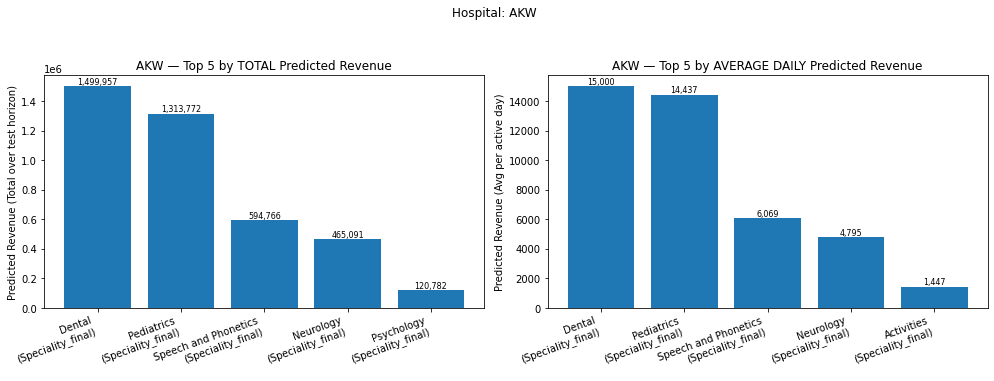

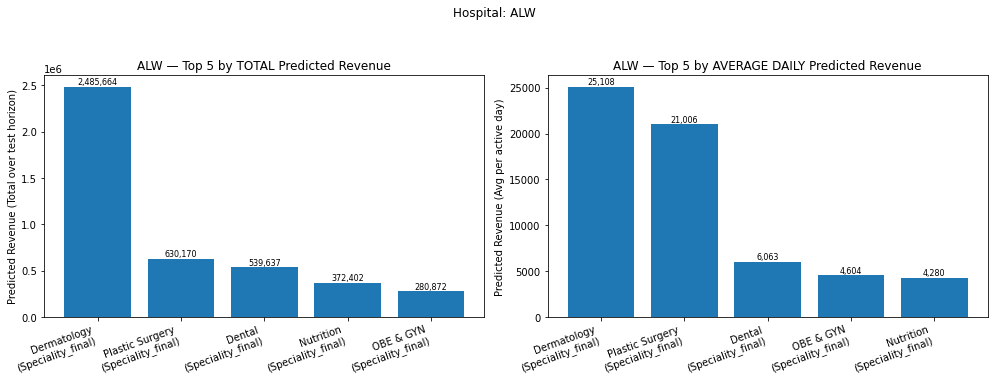

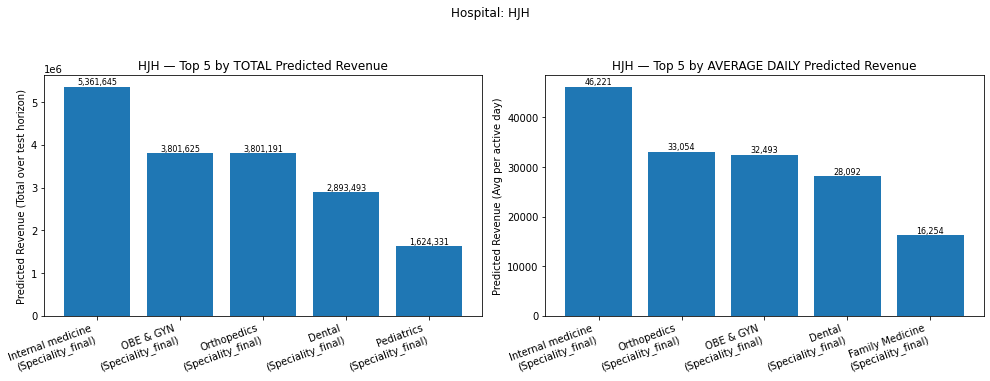

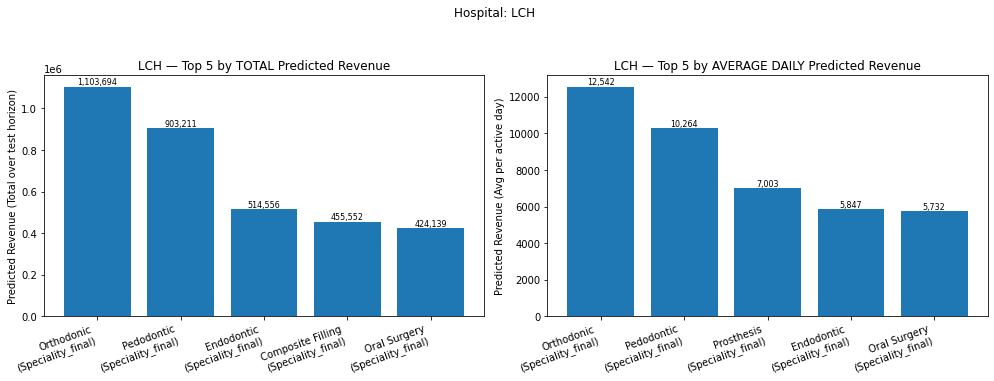

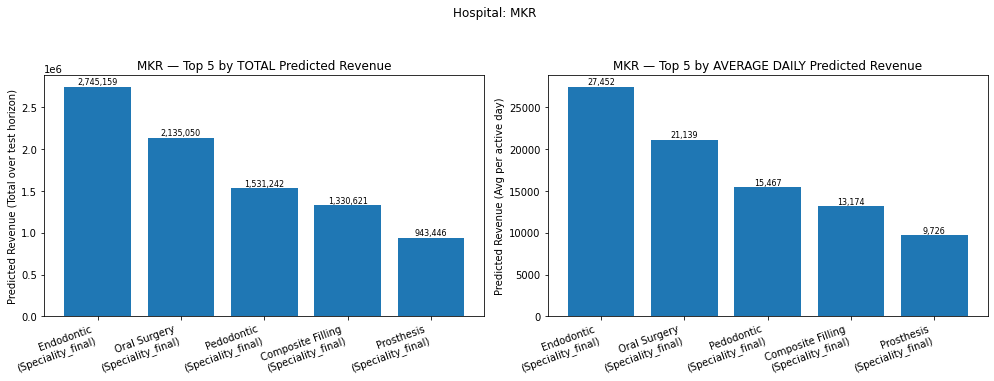

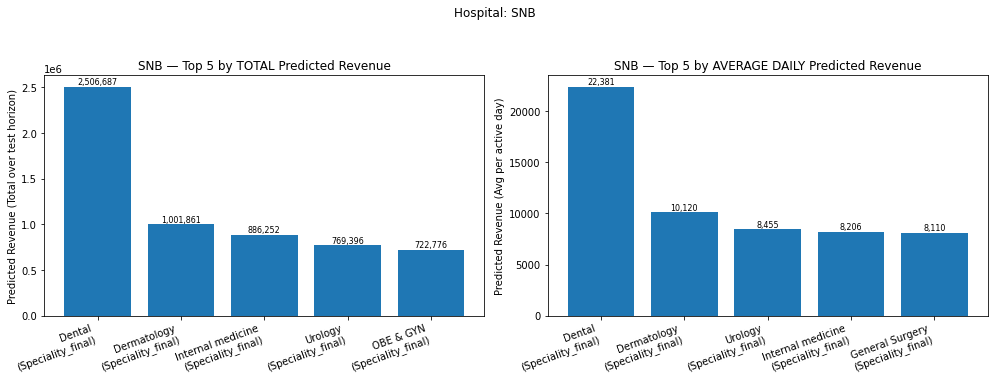

Saved charts to: reports/eda_top_specialty


In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert 'preds_df' in globals() and not preds_df.empty, "preds_df is missing or empty."

# Prep
df = preds_df.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Build summaries
totals = (df.groupby(["ShortName","UnitType","Unit"], as_index=False)["Pred_Revenue"]
            .sum().rename(columns={"Pred_Revenue":"PredRevenue_Total"}))

active_days = (df.groupby(["ShortName","UnitType","Unit"])["Date"]
                 .nunique().reset_index(name="ActiveDays"))

summary = (totals.merge(active_days, on=["ShortName","UnitType","Unit"], how="left"))
summary["PredRevenue_PerDay"] = summary["PredRevenue_Total"] / summary["ActiveDays"].replace(0, np.nan)

# Output dir
outdir = "reports/eda_top_specialty"
os.makedirs(outdir, exist_ok=True)

TOP_N = 5  # bars to show

def _bar_plot(ax, x_labels, values, title, ylabel):
    ax.bar(x_labels, values)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(x_labels, rotation=20, ha="right")
    # annotate bars
    for i, v in enumerate(values):
        ax.text(i, v, f"{v:,.0f}", ha='center', va='bottom', fontsize=8)

# Draw per hospital
for hosp in summary["ShortName"].unique():
    s = summary[summary["ShortName"] == hosp].copy()
    if s.empty:
        continue

    # Top by TOTAL
    top_total = (s.sort_values("PredRevenue_Total", ascending=False)
                   .head(TOP_N))
    # Top by PER DAY
    top_perday = (s.sort_values("PredRevenue_PerDay", ascending=False)
                    .head(TOP_N))

    # Build figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    # Left: total revenue
    labels_total = [f"{u}\n({ut})" for ut, u in zip(top_total["UnitType"], top_total["Unit"])]
    vals_total = top_total["PredRevenue_Total"].values
    _bar_plot(
        axes[0],
        labels_total,
        vals_total,
        title=f"{hosp} — Top {TOP_N} by TOTAL Predicted Revenue",
        ylabel="Predicted Revenue (Total over test horizon)"
    )

    # Right: per-day revenue
    labels_day = [f"{u}\n({ut})" for ut, u in zip(top_perday["UnitType"], top_perday["Unit"])]
    vals_day = top_perday["PredRevenue_PerDay"].values
    _bar_plot(
        axes[1],
        labels_day,
        vals_day,
        title=f"{hosp} — Top {TOP_N} by AVERAGE DAILY Predicted Revenue",
        ylabel="Predicted Revenue (Avg per active day)"
    )

    fig.suptitle(f"Hospital: {hosp}", fontsize=12, y=1.05)
    plt.tight_layout()

    # Save and show
    fname = os.path.join(outdir, f"{hosp.replace('/','-')}_top_specialties.png")
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

print(f"Saved charts to: {outdir}")


# Explanation — Ranking Top Hospitals by Predicted Revenue

## Purpose
Identify **top-performing hospitals** by predicted revenue (and optionally predicted cases) to benchmark performance across the network.

## What the code does
1. **Aggregate predictions**
   - Groups `preds_df` by `ShortName` (hospital).
   - Calculates:
     - `PredRevenue_Total`: total predicted revenue.
     - `ActiveDays`: number of unique days with predictions.
     - `PredRevenue_PerDay`: average daily predicted revenue.
   - (Optional) If `Pred_Cases` exists:
     - `PredCases_Total`: total predicted cases.
     - `PredCases_PerDay`: average daily predicted cases.

2. **Rank hospitals**
   - `top_total`: ranks hospitals by **total predicted revenue**.
   - `top_perday`: ranks hospitals by **average daily predicted revenue**.
   - Prints the top hospital for each ranking.

3. **Visualization**
   - Creates two bar charts (side by side):
     - Left: top 10 hospitals by total predicted revenue.
     - Right: top 10 hospitals by average daily predicted revenue.
   - Annotates each bar with its value.
   - Adds a common title: *"Top-Performing Hospitals by Predicted Revenue"*.
   - Saves chart to `reports/eda_top_hospital/top_hospitals_predicted_revenue.png`.

4. **Optional case plots**
   - If `Pred_Cases` exists and `PLOT_CASES=True`, also produces:
     - Top hospitals by total predicted cases.
     - Top hospitals by average daily predicted cases.
   - Saves as `top_hospitals_predicted_cases.png`.

## Why this matters
- Highlights which hospitals **generate the highest predicted revenue** overall vs on a per-day basis.  
- Adjusts for **active days**, ensuring fairness when some hospitals have shorter test horizons.  
- Supports **strategic decision-making** by comparing performance across facilities.

## Caveats
- Rankings are based on **predicted values**, not actuals — accuracy depends on model quality.  
- Hospitals with fewer active days may have unstable per-day averages.  
- Visualization only shows the **top 10 hospitals**; others are excluded.  
- Case rankings are optional and only computed if prediction columns exist.



Top hospital by TOTAL predicted revenue:


,ShortName,PredRevenue_Total,ActiveDays,PredRevenue_PerDay
0,HJH,3.043691e+07,182,167235.775924



Top hospital by AVERAGE DAILY predicted revenue:


,ShortName,PredRevenue_PerDay,ActiveDays,PredRevenue_Total
0,HJH,167235.775924,182,3.043691e+07


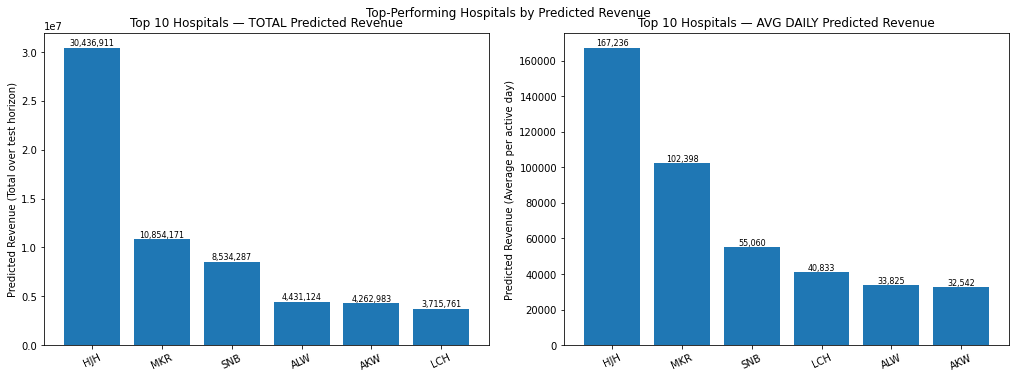

Saved chart: reports/eda_top_hospital\top_hospitals_predicted_revenue.png


In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert 'preds_df' in globals() and not preds_df.empty, "preds_df is missing or empty."

df = preds_df.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# --- Aggregate per hospital ---
agg_h = (df.groupby("ShortName")
           .agg(PredRevenue_Total=("Pred_Revenue","sum"),
                ActiveDays=("Date","nunique"))
           .reset_index())
agg_h["PredRevenue_PerDay"] = agg_h["PredRevenue_Total"] / agg_h["ActiveDays"].replace(0, np.nan)

# Optional (if predicted cases exist)
if "Pred_Cases" in df.columns:
    cases_tot = df.groupby("ShortName")["Pred_Cases"].sum().reset_index(name="PredCases_Total")
    agg_h = agg_h.merge(cases_tot, on="ShortName", how="left")
    agg_h["PredCases_PerDay"] = agg_h["PredCases_Total"] / agg_h["ActiveDays"].replace(0, np.nan)

# --- Rankings ---
top_total   = agg_h.sort_values("PredRevenue_Total", ascending=False).reset_index(drop=True)
top_perday  = agg_h.sort_values("PredRevenue_PerDay", ascending=False).reset_index(drop=True)

print("\nTop hospital by TOTAL predicted revenue:")
display(top_total.loc[[0], ["ShortName","PredRevenue_Total","ActiveDays","PredRevenue_PerDay"]])

print("\nTop hospital by AVERAGE DAILY predicted revenue:")
display(top_perday.loc[[0], ["ShortName","PredRevenue_PerDay","ActiveDays","PredRevenue_Total"]])

# --- Graphs ---
TOP_N = 10  # number of hospitals to show
outdir = "reports/eda_top_hospital"
os.makedirs(outdir, exist_ok=True)

def annotate_bars(ax, values):
    for i, v in enumerate(values):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Left: TOTAL predicted revenue
x1 = top_total["ShortName"].head(TOP_N).tolist()
y1 = top_total["PredRevenue_Total"].head(TOP_N).values
axes[0].bar(x1, y1)
axes[0].set_title(f"Top {TOP_N} Hospitals — TOTAL Predicted Revenue")
axes[0].set_ylabel("Predicted Revenue (Total over test horizon)")
axes[0].tick_params(axis="x", rotation=25)
annotate_bars(axes[0], y1)

# Right: AVERAGE DAILY predicted revenue
x2 = top_perday["ShortName"].head(TOP_N).tolist()
y2 = top_perday["PredRevenue_PerDay"].head(TOP_N).values
axes[1].bar(x2, y2)
axes[1].set_title(f"Top {TOP_N} Hospitals — AVG DAILY Predicted Revenue")
axes[1].set_ylabel("Predicted Revenue (Average per active day)")
axes[1].tick_params(axis="x", rotation=25)
annotate_bars(axes[1], y2)

fig.suptitle("Top-Performing Hospitals by Predicted Revenue", y=1.02, fontsize=12)
fname = os.path.join(outdir, "top_hospitals_predicted_revenue.png")
fig.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved chart: {fname}")

# --- (Optional) Cases ranking plots ---
PLOT_CASES = False
if PLOT_CASES and "Pred_Cases" in df.columns:
    top_cases_total  = agg_h.sort_values("PredCases_Total", ascending=False).head(TOP_N)
    top_cases_perday = agg_h.sort_values("PredCases_PerDay", ascending=False).head(TOP_N)

    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    x3, y3 = top_cases_total["ShortName"], top_cases_total["PredCases_Total"]
    axes2[0].bar(x3, y3)
    axes2[0].set_title(f"Top {TOP_N} Hospitals — TOTAL Predicted Cases")
    axes2[0].set_ylabel("Predicted Cases (Total)")
    axes2[0].tick_params(axis="x", rotation=25)
    annotate_bars(axes2[0], y3.values)

    x4, y4 = top_cases_perday["ShortName"], top_cases_perday["PredCases_PerDay"]
    axes2[1].bar(x4, y4)
    axes2[1].set_title(f"Top {TOP_N} Hospitals — AVG DAILY Predicted Cases")
    axes2[1].set_ylabel("Predicted Cases (Average per day)")
    axes2[1].tick_params(axis="x", rotation=25)
    annotate_bars(axes2[1], y4.values)

    fig2.suptitle("Top-Performing Hospitals by Predicted Cases", y=1.02, fontsize=12)
    fname2 = os.path.join(outdir, "top_hospitals_predicted_cases.png")
    fig2.savefig(fname2, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved chart: {fname2}")
